In [4]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split

from sklearn.metrics import precision_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from scipy.io.arff import loadarff
from tqdm import tqdm
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns

import gdown

# Google Drive share links for train and test
train_url = "https://drive.google.com/uc?id=1yVsTc5V62ASrDJp6dsMSHyYt-dFhhc-i"
test_url  = "https://drive.google.com/uc?id=1bH_IOB3_XxuV2yR--HcXAk85pFtpK3Y5"

# Download via gdown
gdown.download(train_url, "train.json", quiet=False)
gdown.download(test_url, "test.json", quiet=False)

# Load into DataFrames (same variables as before)
data_train = pd.read_json("train.json")
data_test  = pd.read_json("test.json")


Downloading...
From: https://drive.google.com/uc?id=1yVsTc5V62ASrDJp6dsMSHyYt-dFhhc-i
To: /content/sample_data/train.json
100%|██████████| 39.5M/39.5M [00:00<00:00, 86.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bH_IOB3_XxuV2yR--HcXAk85pFtpK3Y5
To: /content/sample_data/test.json
100%|██████████| 18.1M/18.1M [00:00<00:00, 102MB/s] 


In [5]:
data_train

,api_call_sequence,is_malware
0,"[LdrGetDllHandle, LdrGetProcedureAddress, LdrL...",1
1,"[NtAllocateVirtualMemory, LdrLoadDll, LdrGetPr...",1
2,"[FindResourceExW, LoadResource, FindResourceEx...",1
3,"[FindResourceExW, LoadResource, FindResourceEx...",1
4,"[LdrGetProcedureAddress, SetErrorMode, LdrLoad...",1
...,...,...
16320,"[LdrGetProcedureAddress, LdrLoadDll, LdrGetPro...",1
16321,"[NtClose, LdrGetProcedureAddress, CryptCreateH...",1
16322,"[LdrGetProcedureAddress, LdrGetDllHandle, LdrG...",1
16323,"[LdrGetProcedureAddress, LdrGetDllHandle, LdrG...",1


In [6]:
data_test

,api_call_sequence,is_malware
0,"[NtQueryValueKey, NtClose, NtOpenKey, NtQueryV...",1
1,"[LdrGetProcedureAddress, NtClose, NtOpenKey, N...",1
2,"[NtOpenKey, NtQueryValueKey, NtClose, NtOpenKe...",1
3,"[NtAllocateVirtualMemory, LdrLoadDll, LdrGetPr...",1
4,"[NtOpenKey, NtQueryValueKey, NtClose, LdrGetPr...",1
...,...,...
6500,"[SetErrorMode, NtOpenFile, NtClose, SHGetFolde...",0
6501,"[NtProtectVirtualMemory, RegOpenKeyExW, RegQue...",1
6502,"[RegOpenKeyExW, RegQueryValueExW, RegCloseKey,...",1
6503,"[NtQueryValueKey, NtClose, RegOpenKeyExA, RegQ...",1


In [7]:
import pandas as pd

# Count the occurrences of each malware label
malware_counts = data_train['is_malware'].value_counts()
malware_counts_test = data_test['is_malware'].value_counts()


print("Train")
print(malware_counts)
print("Test")
print(malware_counts_test)



Train
is_malware
1    15714
0      611
Name: count, dtype: int64
Test
is_malware
1    6262
0     243
Name: count, dtype: int64


In [8]:
import pandas as pd
api_call_counts = {}
for index, row in data_train.iterrows():
    api_calls = row['api_call_sequence']
    for api_call in api_calls:
        if api_call not in api_call_counts:
            api_call_counts[api_call] = 0
        api_call_counts[api_call] += 1

train_api_call_df = pd.DataFrame(list(api_call_counts.items()), columns=['api_call', 'count'])
train_api_call_df


,api_call,count
0,LdrGetDllHandle,71498
1,LdrGetProcedureAddress,170696
2,LdrLoadDll,91296
3,GetTimeZoneInformation,1050
4,LoadStringW,2921
...,...,...
253,sendto,4
254,recvfrom,2
255,CryptProtectMemory,1
256,GetFileVersionInfoSizeExW,1


In [9]:
import pandas as pd
api_call_counts = {}
for index, row in data_test.iterrows():
    api_calls = row['api_call_sequence']
    for api_call in api_calls:
        if api_call not in api_call_counts:
            api_call_counts[api_call] = 0
        api_call_counts[api_call] += 1

test_api_call_df = pd.DataFrame(list(api_call_counts.items()), columns=['api_call', 'count'])
test_api_call_df

,api_call,count
0,NtQueryValueKey,11776
1,NtClose,31058
2,NtOpenKey,11282
3,NtQueryAttributesFile,935
4,LoadStringA,1148
...,...,...
227,GetAsyncKeyState,8
228,FindWindowExW,5
229,WSASocketA,1
230,RegDeleteValueW,1


Merged DataFrame (with count differences):
                   api_call  count_train  count_test  count_diff
117  LdrGetProcedureAddress       170696       83894       86802
201           RegOpenKeyExW        86046       36634       49412
118              LdrLoadDll        91296       44377       46919
116         LdrGetDllHandle        71498       34096       37402
205        RegQueryValueExW        64074       27331       36743
..                      ...          ...         ...         ...
202        RegQueryInfoKeyA            2           1           1
31       CryptProtectMemory            1           0           1
217      SendNotifyMessageW            1           0           1
237              WSASocketA            0           1          -1
39      EnumServicesStatusA            1           1           0

[261 rows x 4 columns]

API calls only in the train set:
                               api_call  count
152              NetUserGetLocalGroups      1
172       GetFileInformati

/tmp/ipython-input-1018727572.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=counts, palette='viridis')


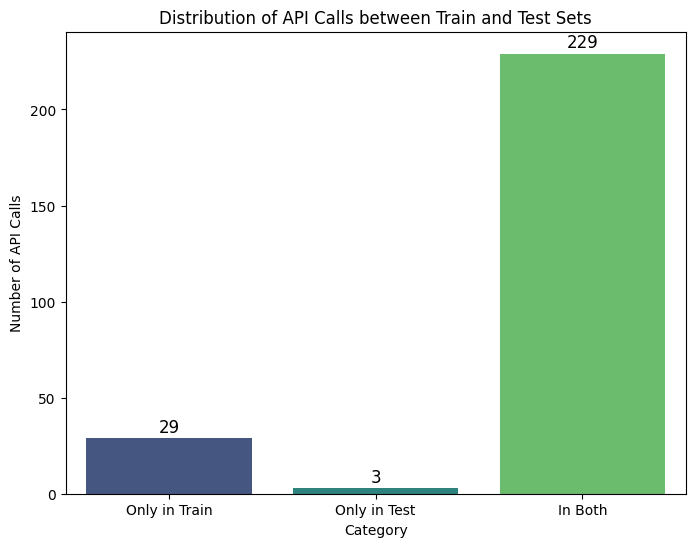

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Merge the two DataFrames on the 'api_call' column
# -------------------------------
merged_df = pd.merge(train_api_call_df, test_api_call_df, on='api_call', how='outer', suffixes=('_train', '_test'))

# Replace missing values with 0 (for API calls not present in one of the sets)
merged_df['count_train'] = merged_df['count_train'].fillna(0).astype(int)
merged_df['count_test'] = merged_df['count_test'].fillna(0).astype(int)

# Calculate the difference between train and test counts
merged_df['count_diff'] = merged_df['count_train'] - merged_df['count_test']

# Sort by the absolute difference to highlight the API calls with the most difference
merged_df = merged_df.sort_values(by='count_diff', key=lambda x: abs(x), ascending=False)

print("Merged DataFrame (with count differences):")
print(merged_df)


# Identify API calls exclusive to train and test
# -------------------------------
# API calls only in the train set
train_only = train_api_call_df[~train_api_call_df['api_call'].isin(test_api_call_df['api_call'])]
print("\nAPI calls only in the train set:\n", train_only)

# API calls only in the test set
test_only = test_api_call_df[~test_api_call_df['api_call'].isin(train_api_call_df['api_call'])]
print("\nAPI calls only in the test set:\n", test_only)

# -------------------------------
# Summary counts of API calls in each category
# -------------------------------
n_train_only = train_only.shape[0]
n_test_only = test_only.shape[0]
n_in_both = merged_df[(merged_df['count_train'] > 0) & (merged_df['count_test'] > 0)].shape[0]

print("\nNumber of API calls only in train: {}".format(n_train_only))
print("Number of API calls only in test: {}".format(n_test_only))
print("Number of API calls present in both sets: {}".format(n_in_both))

# -------------------------------
# Bar Plot: Distribution of API calls across Train and Test sets
# -------------------------------
categories = ['Only in Train', 'Only in Test', 'In Both']
counts = [n_train_only, n_test_only, n_in_both]

plt.figure(figsize=(8, 6))
sns.barplot(x=categories, y=counts, palette='viridis')
plt.title("Distribution of API Calls between Train and Test Sets")
plt.ylabel("Number of API Calls")
plt.xlabel("Category")
for i, count in enumerate(counts):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=12)
plt.show()


In [11]:
!pip install numpy
!pip install gensim
!pip install --upgrade joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 99.2 MB/s eta 0:00:00


# Pre-Processing


In [12]:
# ===============================
# 1. Load Libraries and Data
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast


from sklearn.manifold import TSNE

from sklearn.feature_extraction.text import CountVectorizer

# -------------------------------
# Load the training and test datasets.
# -------------------------------
train_df = pd.read_json('train.json')
test_df  = pd.read_json('test.json')

# If the 'api_call_sequence' column is stored as string representation of a list, convert it:
def convert_to_list(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return x.split()  # fallback split if different formatting
    return x

train_df['api_call_sequence'] = train_df['api_call_sequence'].apply(convert_to_list)
test_df['api_call_sequence']  = test_df['api_call_sequence'].apply(convert_to_list)


print("Columns in Train are:", train_df.columns)
print("Columns in Test are:", test_df.columns)




# Check for duplicates in the training set
# Convert the 'api_call_sequence' column to tuples before checking for duplicates
duplicates_train = train_df.apply(lambda row: tuple(row['api_call_sequence']), axis=1).duplicated()
num_duplicates_train = duplicates_train.sum()
print(f"Number of duplicate rows in Train: {num_duplicates_train}")

# Remove duplicates from train set
train_df = train_df[~duplicates_train]  # Using the boolean series to filter
print("Train DataFrame shape after removing duplicates:", train_df.shape)

# Check for duplicates in the test set
# Convert the 'api_call_sequence' column to tuples before checking for duplicates
duplicates_test = test_df.apply(lambda row: tuple(row['api_call_sequence']), axis=1).duplicated()
num_duplicates_test = duplicates_test.sum()
print(f"Number of duplicate rows in Test: {num_duplicates_test}")

# Remove duplicates from test set
test_df = test_df[~duplicates_test]  # Using the boolean series to filter
print("Test DataFrame shape after removing duplicates:", test_df.shape)

Columns in Train are: Index(['api_call_sequence', 'is_malware'], dtype='object')
Columns in Test are: Index(['api_call_sequence', 'is_malware'], dtype='object')
Number of duplicate rows in Train: 0
Train DataFrame shape after removing duplicates: (16325, 2)
Number of duplicate rows in Test: 0
Test DataFrame shape after removing duplicates: (6505, 2)


Sequence length statistics (Train):
count    16325.000000
mean        75.030812
std          8.951411
min         60.000000
25%         67.000000
50%         75.000000
75%         83.000000
max         90.000000
Name: seq_length, dtype: float64


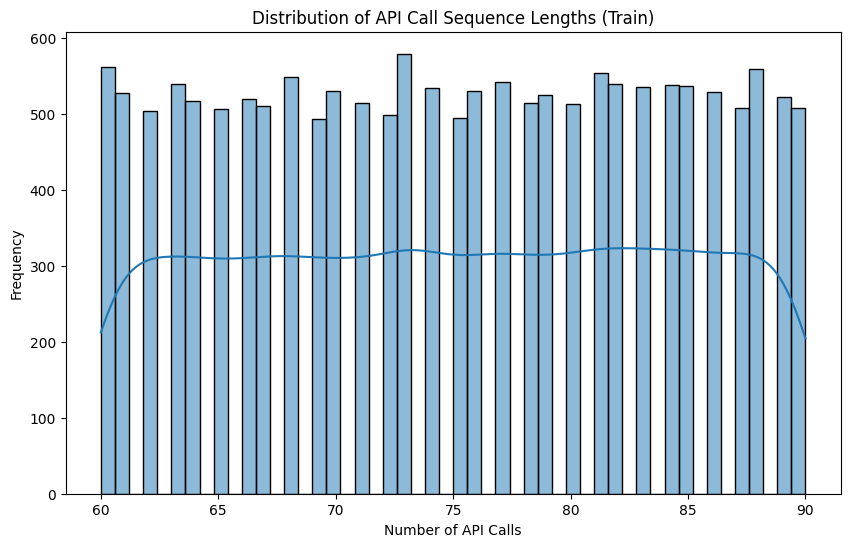

Top 10 most common API calls:
[('LdrGetProcedureAddress', 170696), ('LdrLoadDll', 91296), ('RegOpenKeyExW', 86046), ('LdrGetDllHandle', 71498), ('NtClose', 67682), ('RegQueryValueExW', 64074), ('RegCloseKey', 61993), ('NtAllocateVirtualMemory', 54789), ('LoadResource', 36327), ('FindResourceExW', 32102)]
Vocabulary size: 259
Missing values in Train:
api_call_sequence    0
is_malware           0
seq_length           0
dtype: int64
Missing values in Test:
api_call_sequence    0
is_malware           0
dtype: int64
Preprocessing pipeline complete!


In [13]:

# Compute and plot distribution of sequence lengths in the training set
train_df['seq_length'] = train_df['api_call_sequence'].apply(len)
print("Sequence length statistics (Train):")
print(train_df['seq_length'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(train_df['seq_length'], bins=50, kde=True)
plt.title("Distribution of API Call Sequence Lengths (Train)")
plt.xlabel("Number of API Calls")
plt.ylabel("Frequency")
plt.show()


from collections import Counter

# Extract all API calls from the training set
all_calls = [api for seq in train_df['api_call_sequence'] for api in seq]
call_counter = Counter(all_calls)
print("Top 10 most common API calls:")
print(call_counter.most_common(10))

# Build a vocabulary list and add a special <UNK> token for out-of-vocabulary API calls.
vocab = list(call_counter.keys())
vocab.append("<UNK>")
print("Vocabulary size:", len(vocab))

# Create a mapping: API call -> integer ID
api_to_int = {api: idx for idx, api in enumerate(vocab, start=1)}
int_to_api = {idx: api for api, idx in api_to_int.items()}




# Check for Missing Values:

print("Missing values in Train:")
print(train_df.isnull().sum())
print("Missing values in Test:")
print(test_df.isnull().sum())


print("Preprocessing pipeline complete!")


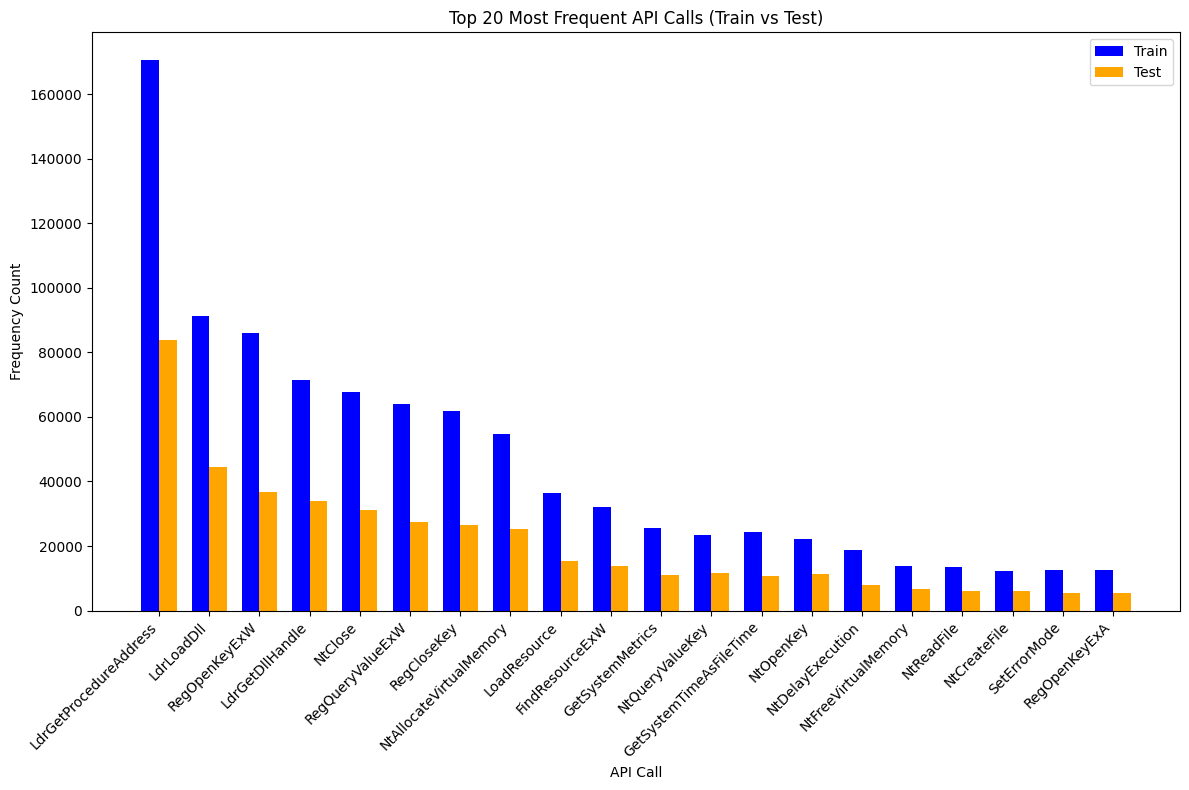

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


# Calculate the frequency of each API call in the Train dataset
train_calls = [api for seq in train_df['api_call_sequence'] for api in seq]
train_counter = Counter(train_calls)
train_freq_df = pd.DataFrame(list(train_counter.items()), columns=['api_call', 'count_train'])

# Calculate the frequency of each API call in the Test dataset
test_calls = [api for seq in test_df['api_call_sequence'] for api in seq]
test_counter = Counter(test_calls)
test_freq_df = pd.DataFrame(list(test_counter.items()), columns=['api_call', 'count_test'])

# Merge the two DataFrames on API calls (using an outer join to include all)
freq_df = pd.merge(train_freq_df, test_freq_df, on='api_call', how='outer').fillna(0)
freq_df['count_train'] = freq_df['count_train'].astype(int)
freq_df['count_test'] = freq_df['count_test'].astype(int)

# To compare, sort by the total (train + test) and select, for example, the top 20 API calls
freq_df['total'] = freq_df['count_train'] + freq_df['count_test']
freq_df = freq_df.sort_values(by='total', ascending=False)
topN = 20
top_freq_df = freq_df.head(topN)

# Visualization: bar chart of the most frequent API calls, split by Train and Test
plt.figure(figsize=(12,8))
indices = range(len(top_freq_df))
width = 0.35

plt.bar([i - width/2 for i in indices], top_freq_df['count_train'], width=width, color='blue', label='Train')
plt.bar([i + width/2 for i in indices], top_freq_df['count_test'], width=width, color='orange', label='Test')

plt.xticks(indices, top_freq_df['api_call'], rotation=45, ha='right')
plt.xlabel("API Call")
plt.ylabel("Frequency Count")
plt.title("Top 20 Most Frequent API Calls (Train vs Test)")
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
train_text = [" ".join(seq) for seq in train_df['api_call_sequence']]
test_text  = [" ".join(seq) for seq in test_df['api_call_sequence']]


In [16]:
from sklearn.feature_extraction.text import CountVectorizer

# learn vocabulary from training sequences
vectorizer = CountVectorizer(token_pattern=r"[^ ]+", lowercase=False)
# token_pattern disables default word rules and treats each space-separated API call as a token

vectorizer.fit(train_text)

train_vocab = vectorizer.vocabulary_
print("Train vocabulary size:", len(train_vocab))


Train vocabulary size: 258


In [17]:
# Transform into sparse matrices
X_train = vectorizer.transform(train_text)
X_test  = vectorizer.transform(test_text)

y_train = train_df["is_malware"].values
y_test  = test_df["is_malware"].values

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)




X_train shape: (16325, 258)
X_test shape: (6505, 258)


In [18]:
#Sparsity stats
import numpy as np

nnz_train = X_train.getnnz(axis=1)
nnz_test  = X_test.getnnz(axis=1)

print("Avg non-zero per train row:", nnz_train.mean())
print("Avg non-zero per test row:", nnz_test.mean())
print("Ratio (train):", nnz_train.mean() / X_train.shape[1])
print("Ratio (test): ", nnz_test.mean()  / X_test.shape[1])


Avg non-zero per train row: 21.94707503828484
Avg non-zero per test row: 24.278247501921598
Ratio (train): 0.0850661823189335
Ratio (test):  0.09410173450357208



==== Logistic Regression Results ====

Training time: 27.230 seconds
Accuracy: 0.8801

Classification Report:

              precision    recall  f1-score   support

           0     0.2134    0.8230    0.3390       243
           1     0.9923    0.8823    0.9341      6262

    accuracy                         0.8801      6505
   macro avg     0.6029    0.8527    0.6365      6505
weighted avg     0.9632    0.8801    0.9118      6505


Confusion Matrix:
 [[ 200   43]
 [ 737 5525]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


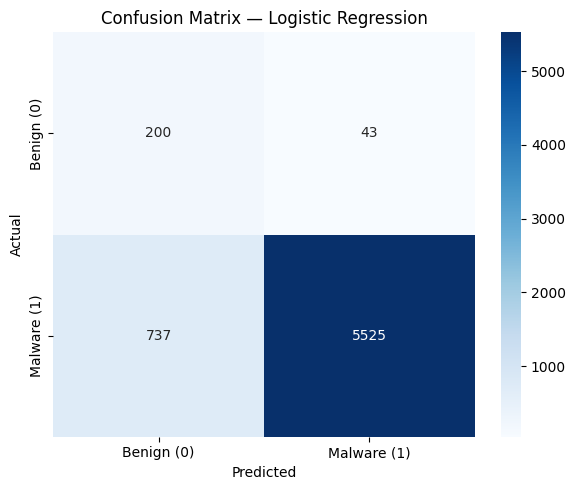

In [19]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# -----------------------------
# Train Logistic Regression
# -----------------------------
clf = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    n_jobs=-1,
    solver='saga'   # best solver for sparse data
)

start_time = time.time()
clf.fit(X_train, y_train)
end_time = time.time()

train_time = end_time - start_time

# -----------------------------
# Predictions
# -----------------------------
y_pred = clf.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
print(f"\n==== Logistic Regression Results ====\n")
print(f"Training time: {train_time:.3f} seconds")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# -----------------------------
# Confusion Matrix Plot
# -----------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign (0)", "Malware (1)"],
            yticklabels=["Benign (0)", "Malware (1)"])
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# TASK-2 - FFNN


 FFNN MODEL WITH O-PADDING


Unique sequence lengths in TRAIN: 31
Unique sequence lengths in TEST : 31
→ Training sequences have variable lengths.
→ Test sequences have variable lengths.

=== Sequence Length Statistics (TRAIN) ===
count    16325.000000
mean        75.030812
std          8.951411
min         60.000000
25%         67.000000
50%         75.000000
75%         83.000000
max         90.000000
Name: seq_length, dtype: float64

=== Sequence Length Statistics (TEST) ===
count    6505.000000
mean       86.331130
std         9.113511
min        70.000000
25%        79.000000
50%        87.000000
75%        94.000000
max       100.000000
Name: seq_length, dtype: float64


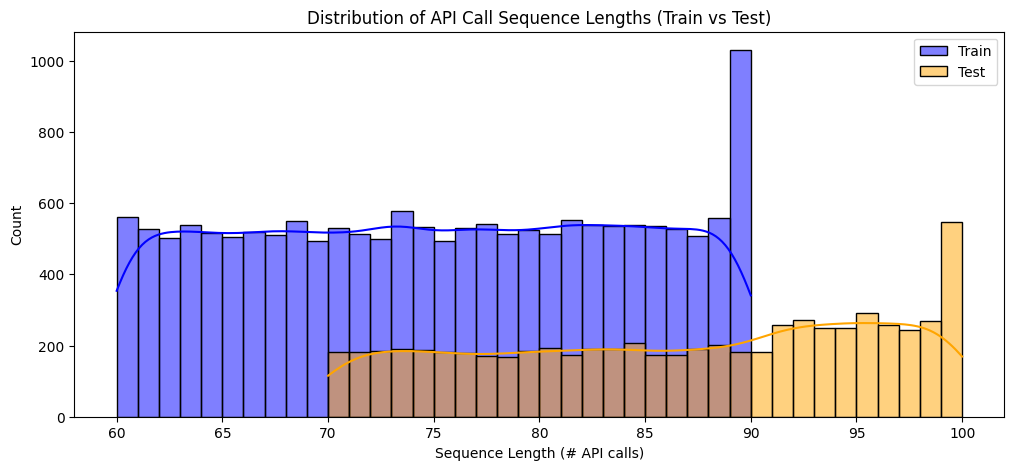

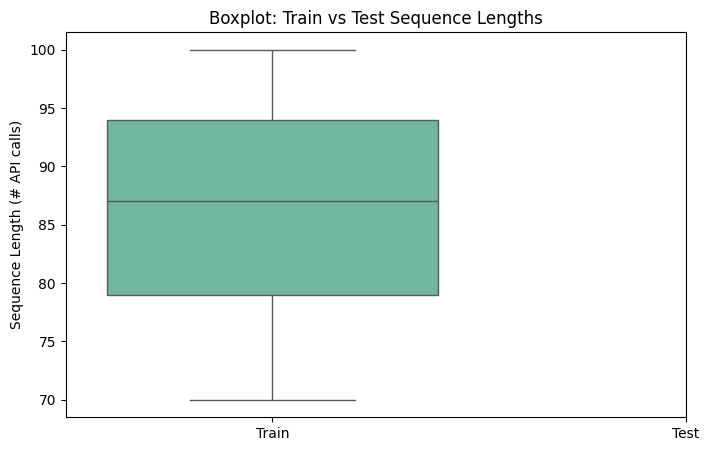


Conclusion: Train and test do NOT have identical sequence length distributions.


In [20]:
# =============================================
# TASK 2 — Sequence Length Analysis
# =============================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure sequences exist in both DataFrames
# (train_df and test_df already created in Task 1)
# If seq_length not present, compute it again:
train_df['seq_length'] = train_df['api_call_sequence'].apply(len)
test_df['seq_length']  = test_df['api_call_sequence'].apply(len)

# ---------------------------------------------
# 1) Do all sequences have the same number of API calls?
# ---------------------------------------------
train_unique_lengths = train_df['seq_length'].nunique()
test_unique_lengths  = test_df['seq_length'].nunique()

print("Unique sequence lengths in TRAIN:", train_unique_lengths)
print("Unique sequence lengths in TEST :", test_unique_lengths)

if train_unique_lengths == 1:
    print("→ All training sequences have the same length.")
else:
    print("→ Training sequences have variable lengths.")

if test_unique_lengths == 1:
    print("→ All test sequences have the same length.")
else:
    print("→ Test sequences have variable lengths.")

# ---------------------------------------------
# 2) Summary statistics for train and test
# ---------------------------------------------
print("\n=== Sequence Length Statistics (TRAIN) ===")
print(train_df['seq_length'].describe())

print("\n=== Sequence Length Statistics (TEST) ===")
print(test_df['seq_length'].describe())

# ---------------------------------------------
# 3) Plot distribution of lengths (Histograms)
# ---------------------------------------------
plt.figure(figsize=(12,5))
sns.histplot(train_df['seq_length'], color="blue", kde=True, bins=30, label="Train")
sns.histplot(test_df['seq_length'],  color="orange", kde=True, bins=30, label="Test")
plt.title("Distribution of API Call Sequence Lengths (Train vs Test)")
plt.xlabel("Sequence Length (# API calls)")
plt.ylabel("Count")
plt.legend()
plt.show()

# ---------------------------------------------
# 4) Boxplot for direct comparison
# ---------------------------------------------
plt.figure(figsize=(8,5))
sns.boxplot(data=[train_df['seq_length'], test_df['seq_length']],
            orient='v', palette="Set2")
plt.xticks([0,1], ["Train", "Test"])
plt.ylabel("Sequence Length (# API calls)")
plt.title("Boxplot: Train vs Test Sequence Lengths")
plt.show()

# ---------------------------------------------
# 5) High-level conclusion
# ---------------------------------------------
if train_df['seq_length'].describe().equals(test_df['seq_length'].describe()):
    print("\nConclusion: Train and test have identical sequence length distributions.")
else:
    print("\nConclusion: Train and test do NOT have identical sequence length distributions.")


In [21]:
def encode_seq(seq, mapping):
    return [mapping.get(token, mapping["<UNK>"]) for token in seq]

# Encode sequences in training and test sets
train_df['seq_encoded'] = train_df['api_call_sequence'].apply(lambda x: encode_seq(x, api_to_int))
test_df['seq_encoded']  = test_df['api_call_sequence'].apply(lambda x: encode_seq(x, api_to_int))

In [22]:
train_df

,api_call_sequence,is_malware,seq_length,seq_encoded
0,"[LdrGetDllHandle, LdrGetProcedureAddress, LdrL...",1,73,"[1, 2, 3, 2, 1, 2, 4, 5, 6, 7, 8, 1, 2, 1, 2, ..."
1,"[NtAllocateVirtualMemory, LdrLoadDll, LdrGetPr...",1,88,"[15, 3, 2, 18, 19, 20, 18, 21, 22, 23, 24, 25,..."
2,"[FindResourceExW, LoadResource, FindResourceEx...",1,79,"[11, 13, 11, 13, 11, 13, 11, 13, 11, 13, 11, 1..."
3,"[FindResourceExW, LoadResource, FindResourceEx...",1,71,"[11, 13, 11, 13, 11, 13, 11, 13, 11, 13, 11, 1..."
4,"[LdrGetProcedureAddress, SetErrorMode, LdrLoad...",1,63,"[2, 9, 3, 9, 10, 11, 13, 11, 13, 11, 13, 11, 1..."
...,...,...,...,...
16320,"[LdrGetProcedureAddress, LdrLoadDll, LdrGetPro...",1,64,"[2, 3, 2, 3, 2, 3, 2, 3, 2, 24, 18, 15, 32, 15..."
16321,"[NtClose, LdrGetProcedureAddress, CryptCreateH...",1,78,"[14, 2, 48, 2, 49, 2, 36, 50, 51, 52, 14, 6, 7..."
16322,"[LdrGetProcedureAddress, LdrGetDllHandle, LdrG...",1,84,"[2, 1, 2, 10, 96, 3, 2, 11, 13, 11, 13, 1, 2, ..."
16323,"[LdrGetProcedureAddress, LdrGetDllHandle, LdrG...",1,62,"[2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, ..."


In [23]:

test_df.drop(columns=['api_call_sequence'], inplace=True)

In [24]:
train_df.drop(columns=['api_call_sequence', 'seq_length'], inplace=True)
train_df

,is_malware,seq_encoded
0,1,"[1, 2, 3, 2, 1, 2, 4, 5, 6, 7, 8, 1, 2, 1, 2, ..."
1,1,"[15, 3, 2, 18, 19, 20, 18, 21, 22, 23, 24, 25,..."
2,1,"[11, 13, 11, 13, 11, 13, 11, 13, 11, 13, 11, 1..."
3,1,"[11, 13, 11, 13, 11, 13, 11, 13, 11, 13, 11, 1..."
4,1,"[2, 9, 3, 9, 10, 11, 13, 11, 13, 11, 13, 11, 1..."
...,...,...
16320,1,"[2, 3, 2, 3, 2, 3, 2, 3, 2, 24, 18, 15, 32, 15..."
16321,1,"[14, 2, 48, 2, 49, 2, 36, 50, 51, 52, 14, 6, 7..."
16322,1,"[2, 1, 2, 10, 96, 3, 2, 11, 13, 11, 13, 1, 2, ..."
16323,1,"[2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, ..."


In [25]:
test_df

,is_malware,seq_length,seq_encoded
0,1,98,"[26, 14, 21, 26, 14, 47, 33, 15, 33, 1, 2, 1, ..."
1,1,98,"[2, 14, 21, 26, 14, 21, 26, 14, 3, 2, 29, 36, ..."
2,1,99,"[21, 26, 14, 21, 26, 14, 1, 2, 1, 2, 1, 2, 19,..."
3,1,85,"[15, 3, 2, 3, 2, 18, 39, 40, 8, 3, 2, 19, 3, 2..."
4,1,80,"[21, 26, 14, 2, 48, 2, 49, 2, 36, 50, 51, 52, ..."
...,...,...,...
6500,0,75,"[9, 101, 14, 117, 9, 44, 9, 101, 14, 20, 117, ..."
6501,1,83,"[24, 6, 7, 8, 61, 15, 24, 15, 32, 24, 2, 6, 7,..."
6502,1,70,"[6, 7, 8, 6, 7, 8, 19, 1, 2, 6, 31, 3, 2, 19, ..."
6503,1,96,"[26, 14, 39, 40, 8, 22, 26, 14, 3, 2, 3, 2, 3,..."


In [26]:
max_len = train_df['seq_encoded'].apply(len).max()
max_len

90

In [27]:
max_len_train = train_df['seq_encoded'].apply(len).max()

In [28]:
# ============================================
# Pad/truncate using TRAIN max only
# ============================================

from keras.utils import pad_sequences
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split

print("max_len_train =", max_len_train)

#  Pad ONLY to train max_len (no test peeking)
X_train_padded = pad_sequences(
    train_df['seq_encoded'],
    maxlen=max_len_train,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    test_df['seq_encoded'],
    maxlen=max_len_train,
    padding='post',
    truncating='post'
)

print("Train padded shape:", X_train_padded.shape)
print("Test padded shape:",  X_test_padded.shape)

#  Count how many test sequences were truncated
test_lengths = test_df['seq_encoded'].apply(len)
num_truncated = (test_lengths > max_len_train).sum()
pct_truncated = 100 * num_truncated / len(test_df)
print(f"Test sequences truncated: {num_truncated} ({pct_truncated:.2f}%)")

#  Convert to Torch tensors (FFNN requires long dtype for embeddings)
Xtr = torch.tensor(X_train_padded, dtype=torch.long)
Xte = torch.tensor(X_test_padded,  dtype=torch.long)
ytr = torch.tensor(train_df['is_malware'].values, dtype=torch.float32)
yte = torch.tensor(test_df['is_malware'].values,  dtype=torch.float32)

print("Torch tensor shapes:")
print("Xtr:", Xtr.shape, "Xte:", Xte.shape)
print("ytr:", ytr.shape, "yte:", yte.shape)

#  Rebuild Dataset + DataLoaders (80/20 split)
full_ds = TensorDataset(Xtr, ytr)

train_size = int(0.8 * len(full_ds))
val_size   = len(full_ds) - train_size

train_ds, val_ds = random_split(full_ds, [train_size, val_size])

batch_size = 64

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(Xte, yte), batch_size=batch_size, shuffle=False)

print("DataLoaders ready:")
print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(Xte))


max_len_train = 90
Train padded shape: (16325, 90)
Test padded shape: (6505, 90)
Test sequences truncated: 2639 (40.57%)
Torch tensor shapes:
Xtr: torch.Size([16325, 90]) Xte: torch.Size([6505, 90])
ytr: torch.Size([16325]) yte: torch.Size([6505])
DataLoaders ready:
Train: 13060 Val: 3265 Test: 6505


## FFNN with SEQ-ID

### Simple 256 -> 64, without BatchNorm and DropOut

Ep 001  train=0.2882  val=0.2378
Ep 002  train=0.2332  val=0.2273
Ep 003  train=0.2199  val=0.2185
Ep 004  train=0.2092  val=0.2114
Ep 005  train=0.1992  val=0.2042
Ep 006  train=0.1902  val=0.1983
Ep 007  train=0.1810  val=0.1924
Ep 008  train=0.1697  val=0.1872
Ep 009  train=0.1641  val=0.1846
Ep 010  train=0.1477  val=0.1834
Ep 011  train=0.1369  val=0.1788
Ep 012  train=0.1253  val=0.1746
Ep 013  train=0.1122  val=0.1815
Ep 014  train=0.0990  val=0.1823
Ep 015  train=0.0899  val=0.1761
Ep 016  train=0.0769  val=0.1835
Ep 017  train=0.0693  val=0.1797
Ep 018  train=0.0650  val=0.1864
Ep 019  train=0.0573  val=0.2121
Ep 020  train=0.0461  val=0.2103
Ep 021  train=0.0461  val=0.2193
Ep 022  train=0.0402  val=0.2254
Ep 023  train=0.0321  val=0.2395
Ep 024  train=0.0351  val=0.2717
Ep 025  train=0.0364  val=0.2574
Ep 026  train=0.0229  val=0.2961
Ep 027  train=0.0400  val=0.2994
early-stop


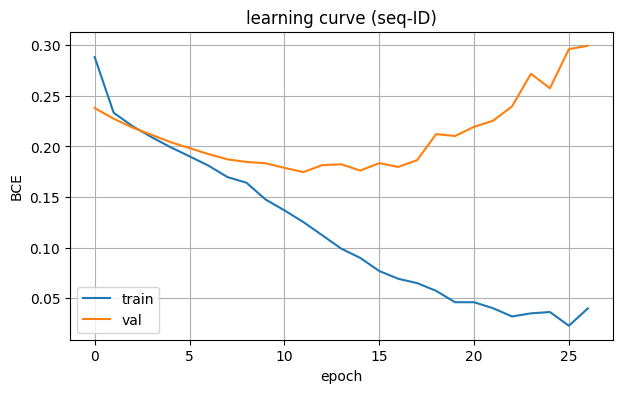

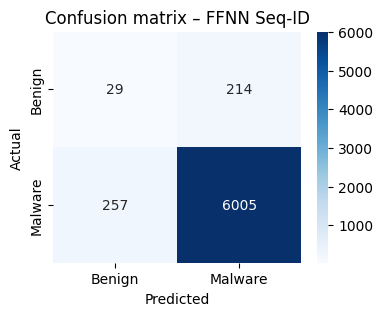

              precision    recall  f1-score   support

      Benign       0.10      0.12      0.11       243
     Malware       0.97      0.96      0.96      6262

    accuracy                           0.93      6505
   macro avg       0.53      0.54      0.54      6505
weighted avg       0.93      0.93      0.93      6505

F1-macro : 0.5360
ROC-AUC  : 0.5626
PR-AUC   : 0.9678


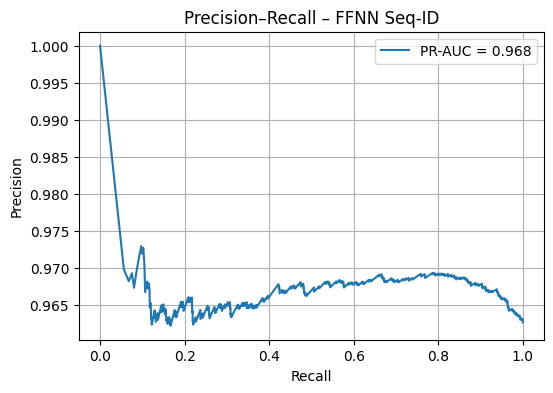

In [29]:
import torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, roc_auc_score,
                             precision_recall_curve, auc)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Xtr = torch.tensor(X_train_padded, dtype=torch.float32)
Xte = torch.tensor(X_test_padded,  dtype=torch.float32)
ytr = torch.tensor(y_train,        dtype=torch.float32)
yte = torch.tensor(y_test,         dtype=torch.float32)

full_ds = TensorDataset(Xtr, ytr)
te_ds   = TensorDataset(Xte, yte)

tr_sz   = int(0.8 * len(full_ds))
va_sz   = len(full_ds) - tr_sz
tr_ds, va_ds = random_split(full_ds, [tr_sz, va_sz])

tr_ld  = DataLoader(tr_ds, batch_size=64, shuffle=True)
va_ld  = DataLoader(va_ds, batch_size=64)
te_ld  = DataLoader(te_ds, batch_size=64)

# FNN with no embeddings
class FFNN_SeqID(nn.Module):
    def __init__(self, seq_len:int):
        super().__init__()
        self.seq_len = seq_len
        self.net = nn.Sequential(
            nn.Linear(seq_len, 256),
            #nn.BatchNorm1d(256),
            nn.ReLU(),
            #nn.Dropout(0.30),

            #nn.Linear(256,128),
            #nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.30),

            nn.Linear(256,64),
           # nn.BatchNorm1d(64),
            nn.ReLU(),
           # nn.Dropout(0.30),

           # nn.Linear(64,32),
           # nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(0.30),

           # nn.Linear(32,16),
           # nn.BatchNorm1d(16),  nn.ReLU(), nn.Dropout(0.30),

            nn.Linear(64,1)                    # logits
        )

    def forward(self,x):
        x = x.view(x.size(0), -1)
        return self.net(x).squeeze(1)  # logits (B,)

seq_len = Xtr.shape[1]
model   = FFNN_SeqID(seq_len).to(device)

# loss and optimizer
crit = nn.BCEWithLogitsLoss()
opt  = optim.AdamW(model.parameters(), lr=5e-4)
sched = optim.lr_scheduler.OneCycleLR(
            opt, max_lr=5e-4,
            epochs=100, steps_per_epoch=len(tr_ld)
        )


# training
epochs, patience = 100, 15
hist_tr, hist_va = [], []
best_va, wait = 1e9, 0

for ep in range(1, epochs+1):
    # ---- train ----
    model.train(); run=0.
    for xb,yb in tr_ld:
        xb,yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward(); opt.step(); sched.step()
        run += loss.item()*xb.size(0)
    hist_tr.append(run/len(tr_ds))

    # ---- val ----
    model.eval(); run=0.
    with torch.no_grad():
        for xb,yb in va_ld:
            xb,yb = xb.to(device), yb.to(device)
            run += crit(model(xb), yb).item()*xb.size(0)
    va_loss = run/len(va_ds); hist_va.append(va_loss)
    print(f"Ep {ep:03d}  train={hist_tr[-1]:.4f}  val={va_loss:.4f}")

    if va_loss < best_va:
        best_va, wait, best_w = va_loss, 0, model.state_dict()
    else:
        wait += 1
        if wait >= patience:
            print("early-stop"); break

model.load_state_dict(best_w)


plt.figure(figsize=(7,4))
plt.plot(hist_tr, label='train'); plt.plot(hist_va, label='val')
plt.xlabel('epoch'); plt.ylabel('BCE'); plt.title('learning curve (seq-ID)')
plt.legend(); plt.grid(); plt.show()

# testing
model.eval(); p_test, y_test_arr = [], []
with torch.no_grad():
    for xb,yb in te_ld:
        p_test.append(torch.sigmoid(model(xb.to(device))).cpu())
        y_test_arr.append(yb)
p_test = torch.cat(p_test).numpy().ravel()
y_test_arr = torch.cat(y_test_arr).numpy().ravel()
pred = (p_test >= 0.5).astype(int)

cm = confusion_matrix(y_test_arr, pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malware'],
            yticklabels=['Benign','Malware'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion matrix – FFNN Seq-ID'); plt.show()

print(classification_report(y_test_arr, pred,
                            target_names=['Benign','Malware']))

f1m   = f1_score(y_test_arr, pred, average='macro')
roc   = roc_auc_score(y_test_arr, p_test)
prec, rec, _ = precision_recall_curve(y_test_arr, p_test)
prauc = auc(rec, prec)
print(f'F1-macro : {f1m:.4f}\nROC-AUC  : {roc:.4f}\nPR-AUC   : {prauc:.4f}')

plt.figure(figsize=(6,4))
plt.plot(rec, prec, label=f'PR-AUC = {prauc:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision–Recall – FFNN Seq-ID')
plt.grid(); plt.legend(); plt.show()


### 128 -> 64 -> 32 with batchNorm and DropOut

Ep 001  train=0.6850  val=0.6469
Ep 002  train=0.6541  val=0.6401
Ep 003  train=0.6194  val=0.6054
Ep 004  train=0.5793  val=0.5841
Ep 005  train=0.5351  val=0.5278
Ep 006  train=0.4841  val=0.4867
Ep 007  train=0.4323  val=0.4360
Ep 008  train=0.3767  val=0.3860
Ep 009  train=0.3280  val=0.3210
Ep 010  train=0.2779  val=0.2832
Ep 011  train=0.2404  val=0.2348
Ep 012  train=0.2102  val=0.2078
Ep 013  train=0.1902  val=0.1871
Ep 014  train=0.1757  val=0.1680
Ep 015  train=0.1656  val=0.1571
Ep 016  train=0.1606  val=0.1499
Ep 017  train=0.1528  val=0.1461
Ep 018  train=0.1511  val=0.1435
Ep 019  train=0.1469  val=0.1425
Ep 020  train=0.1407  val=0.1416
Ep 021  train=0.1353  val=0.1395
Ep 022  train=0.1307  val=0.1430
Ep 023  train=0.1270  val=0.1431
Ep 024  train=0.1144  val=0.1510
Ep 025  train=0.1102  val=0.1502
Ep 026  train=0.1063  val=0.1530
Ep 027  train=0.0981  val=0.1638
Ep 028  train=0.0946  val=0.1615
Ep 029  train=0.0850  val=0.1722
Ep 030  train=0.0845  val=0.1737
Ep 031  tr

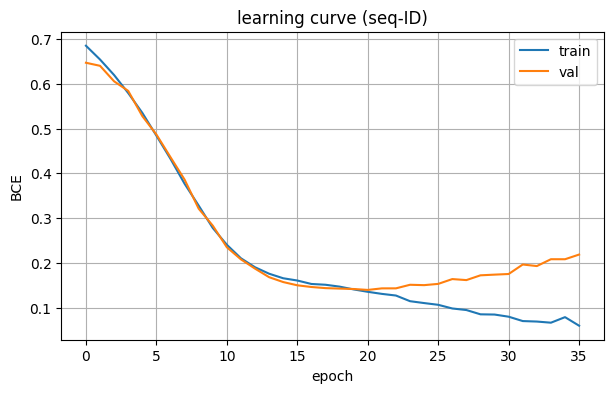

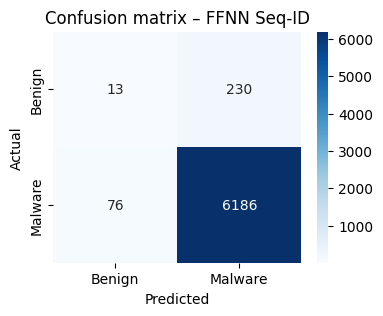

              precision    recall  f1-score   support

      Benign       0.15      0.05      0.08       243
     Malware       0.96      0.99      0.98      6262

    accuracy                           0.95      6505
   macro avg       0.56      0.52      0.53      6505
weighted avg       0.93      0.95      0.94      6505

F1-macro : 0.5271
ROC-AUC  : 0.5776
PR-AUC   : 0.9678


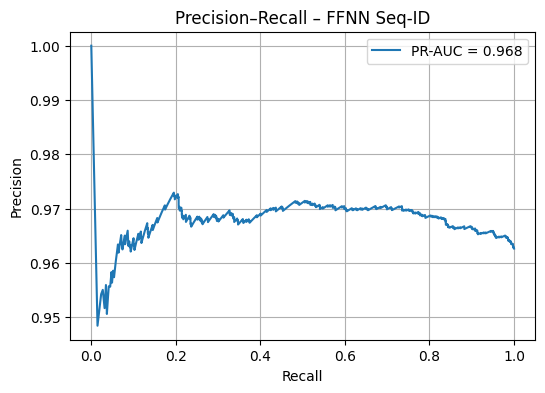

In [30]:

import torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, roc_auc_score,
                             precision_recall_curve, auc)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Xtr = torch.tensor(X_train_padded, dtype=torch.float32)
Xte = torch.tensor(X_test_padded,  dtype=torch.float32)
ytr = torch.tensor(y_train,        dtype=torch.float32)
yte = torch.tensor(y_test,         dtype=torch.float32)

full_ds = TensorDataset(Xtr, ytr)
te_ds   = TensorDataset(Xte, yte)

tr_sz   = int(0.8 * len(full_ds))
va_sz   = len(full_ds) - tr_sz
tr_ds, va_ds = random_split(full_ds, [tr_sz, va_sz])

tr_ld  = DataLoader(tr_ds, batch_size=64, shuffle=True)
va_ld  = DataLoader(va_ds, batch_size=64)
te_ld  = DataLoader(te_ds, batch_size=64)

class FFNN_SeqID(nn.Module):
    def __init__(self, seq_len:int):
        super().__init__()
        self.seq_len = seq_len               # per debug
        self.net = nn.Sequential(
            nn.Linear(seq_len, 128),
            #nn.BatchNorm1d(256),
            nn.ReLU(),
            #nn.Dropout(0.30),

            #nn.Linear(256,128),
            #nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.30),

            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(64,32),
            nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(0.30),

           # nn.Linear(32,16),
           # nn.BatchNorm1d(16),  nn.ReLU(), nn.Dropout(0.30),

            nn.Linear(32,1)                    # logits
        )

    def forward(self,x):
        x = x.view(x.size(0), -1)
        return self.net(x).squeeze(1)  # logits (B,)

seq_len = Xtr.shape[1]
model   = FFNN_SeqID(seq_len).to(device)


crit = nn.BCEWithLogitsLoss()
opt  = optim.AdamW(model.parameters(), lr=5e-4)
sched = optim.lr_scheduler.OneCycleLR(
            opt, max_lr=5e-4,
            epochs=100, steps_per_epoch=len(tr_ld)
        )


epochs, patience = 100, 15
hist_tr, hist_va = [], []
best_va, wait = 1e9, 0

for ep in range(1, epochs+1):
    # ---- train ----
    model.train(); run=0.
    for xb,yb in tr_ld:
        xb,yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward(); opt.step(); sched.step()
        run += loss.item()*xb.size(0)
    hist_tr.append(run/len(tr_ds))

    # ---- val ----
    model.eval(); run=0.
    with torch.no_grad():
        for xb,yb in va_ld:
            xb,yb = xb.to(device), yb.to(device)
            run += crit(model(xb), yb).item()*xb.size(0)
    va_loss = run/len(va_ds); hist_va.append(va_loss)
    print(f"Ep {ep:03d}  train={hist_tr[-1]:.4f}  val={va_loss:.4f}")

    if va_loss < best_va:
        best_va, wait, best_w = va_loss, 0, model.state_dict()
    else:
        wait += 1
        if wait >= patience:
            print("early-stop"); break

model.load_state_dict(best_w)


plt.figure(figsize=(7,4))
plt.plot(hist_tr, label='train'); plt.plot(hist_va, label='val')
plt.xlabel('epoch'); plt.ylabel('BCE'); plt.title('learning curve (seq-ID)')
plt.legend(); plt.grid(); plt.show()

# test evaluation
model.eval(); p_test, y_test_arr = [], []
with torch.no_grad():
    for xb,yb in te_ld:
        p_test.append(torch.sigmoid(model(xb.to(device))).cpu())
        y_test_arr.append(yb)
p_test = torch.cat(p_test).numpy().ravel()
y_test_arr = torch.cat(y_test_arr).numpy().ravel()
pred = (p_test >= 0.5).astype(int)

cm = confusion_matrix(y_test_arr, pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malware'],
            yticklabels=['Benign','Malware'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion matrix – FFNN Seq-ID'); plt.show()

print(classification_report(y_test_arr, pred,
                            target_names=['Benign','Malware']))

f1m   = f1_score(y_test_arr, pred, average='macro')
roc   = roc_auc_score(y_test_arr, p_test)
prec, rec, _ = precision_recall_curve(y_test_arr, p_test)
prauc = auc(rec, prec)
print(f'F1-macro : {f1m:.4f}\nROC-AUC  : {roc:.4f}\nPR-AUC   : {prauc:.4f}')

plt.figure(figsize=(6,4))
plt.plot(rec, prec, label=f'PR-AUC = {prauc:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision–Recall – FFNN Seq-ID')
plt.grid(); plt.legend(); plt.show()


# Embeddings - TASK-2


In [31]:
import torch
import torch.nn as nn
import torch.optim as optim

### Simple embendings FFNN Model

Ep 01  train=0.5760  val=0.5083
Ep 02  train=0.4206  val=0.3257
Ep 03  train=0.2486  val=0.1907
Ep 04  train=0.1711  val=0.1581
Ep 05  train=0.1571  val=0.1521
Ep 06  train=0.1525  val=0.1485
Ep 07  train=0.1480  val=0.1447
Ep 08  train=0.1434  val=0.1412
Ep 09  train=0.1389  val=0.1378
Ep 10  train=0.1348  val=0.1346
Ep 11  train=0.1316  val=0.1318
Ep 12  train=0.1278  val=0.1296
Ep 13  train=0.1245  val=0.1265
Ep 14  train=0.1207  val=0.1239
Ep 15  train=0.1170  val=0.1216
Ep 16  train=0.1117  val=0.1194
Ep 17  train=0.1081  val=0.1179
Ep 18  train=0.1022  val=0.1165
Ep 19  train=0.0990  val=0.1148
Ep 20  train=0.0953  val=0.1150
Ep 21  train=0.0917  val=0.1106
Ep 22  train=0.0903  val=0.1091
Ep 23  train=0.0864  val=0.1142
Ep 24  train=0.0840  val=0.1049
Ep 25  train=0.0806  val=0.1031
Ep 26  train=0.0784  val=0.1050
Ep 27  train=0.0758  val=0.1007
Ep 28  train=0.0747  val=0.1008
Ep 29  train=0.0729  val=0.1009
Ep 30  train=0.0705  val=0.0990
Ep 31  train=0.0690  val=0.1009
Ep 32  t

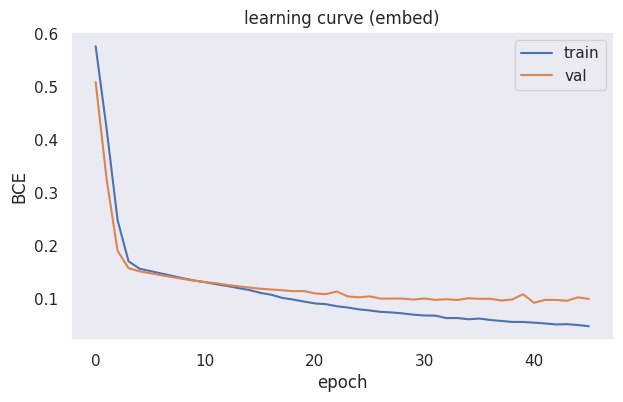

Chosen Threshold = 0.70


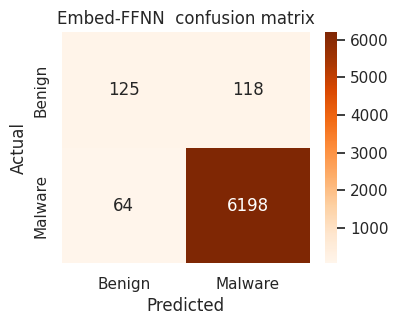

              precision    recall  f1-score   support

      Benign       0.66      0.51      0.58       243
     Malware       0.98      0.99      0.99      6262

    accuracy                           0.97      6505
   macro avg       0.82      0.75      0.78      6505
weighted avg       0.97      0.97      0.97      6505

F1-macro : 0.7821
ROC-AUC  : 0.9299
PR-AUC   : 0.9960


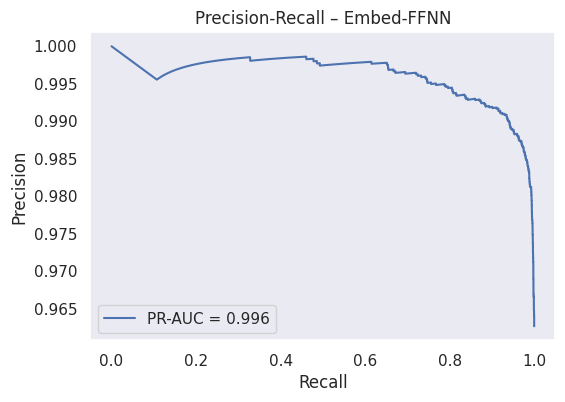

In [32]:
import torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, roc_auc_score,
                             precision_recall_curve, auc)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme()

Xtr = torch.tensor(X_train_padded, dtype=torch.long)
Xte = torch.tensor(X_test_padded,  dtype=torch.long)
ytr = torch.tensor(y_train,        dtype=torch.float32)
yte = torch.tensor(y_test,         dtype=torch.float32)

full_ds = TensorDataset(Xtr, ytr)
te_ds   = TensorDataset(Xte, yte)

tr_sz   = int(0.8 * len(full_ds))
val_sz  = len(full_ds) - tr_sz
tr_ds, val_ds = random_split(full_ds, [tr_sz, val_sz])

tr_ld  = DataLoader(tr_ds,  batch_size=64, shuffle=True)
val_ld = DataLoader(val_ds, batch_size=64, shuffle=False)
te_ld  = DataLoader(te_ds,  batch_size=64, shuffle=False)


# Embedding modified
class EmbedFFNN(nn.Module):
    def __init__(self, vocab_sz:int, emb_dim:int=64):
        super().__init__()
        self.emb  = nn.Embedding(vocab_sz+1, emb_dim, padding_idx=0)
        self.net  = nn.Sequential(
            nn.Linear(emb_dim, 256),
            nn.ReLU(),
            nn.Linear(256,  64),
            nn.ReLU(),
            nn.Linear(64, 1)                      # logits
        )
    def forward(self,x):

        z = self.emb(x).mean(dim=1)               # mean-pool (B,emb_dim)
        return self.net(z).squeeze(1)             # (B,)

vocab_sz = len(vocab)
model    = EmbedFFNN(vocab_sz).to(device)


# loss, optimization
n_benign, n_malw = (y_train==0).sum(), (y_train==1).sum()
pos_w = torch.tensor([1.1], device=device)

crit      = nn.BCEWithLogitsLoss()
optimiser = optim.AdamW(model.parameters(), lr=5e-4)
sched     = optim.lr_scheduler.OneCycleLR(
              optimiser, max_lr=5e-4,
              epochs=100, steps_per_epoch=len(tr_ld))

# training
hist_tr, hist_val = [], []
best_val, wait, patience, epochs = 1e9, 0, 5, 100

for ep in range(1, epochs+1):
    # --- train ---
    model.train(); run=0.
    for x,y in tr_ld:
        x,y = x.to(device), y.to(device)
        optimiser.zero_grad()
        loss = crit(model(x), y)
        loss.backward(); optimiser.step(); sched.step()
        run += loss.item()*x.size(0)
    hist_tr.append(run/len(tr_ds))

    # --- val ---
    model.eval(); run=0.
    with torch.no_grad():
        for x,y in val_ld:
            x,y = x.to(device), y.to(device)
            run += crit(model(x), y).item()*x.size(0)
    val_loss = run/len(val_ds); hist_val.append(val_loss)
    print(f"Ep {ep:02d}  train={hist_tr[-1]:.4f}  val={val_loss:.4f}")

    if val_loss < best_val:
        best_val, wait, best_w = val_loss, 0, model.state_dict()
    else:
        wait += 1
        if wait >= patience:
            print("early-stop"); break

model.load_state_dict(best_w)

# loss curve
plt.figure(figsize=(7,4))
plt.plot(hist_tr, label="train"); plt.plot(hist_val, label="val")
plt.xlabel("epoch"); plt.ylabel("BCE"); plt.title("learning curve (embed)")
plt.legend(); plt.grid(); plt.show()

# treshhold for good validation
model.eval(); p_val, y_val = [], []
with torch.no_grad():
    for x,y in val_ld:
        p_val.append(torch.sigmoid(model(x.to(device))).cpu())
        y_val.append(y)
p_val = torch.cat(p_val).numpy();  y_val = torch.cat(y_val).numpy()

thr_grid = np.linspace(0.05,0.95,19)
best_thr = thr_grid[np.argmax([f1_score(y_val, p_val>=t, average='macro')
                               for t in thr_grid])]
print(f"Chosen Threshold = {best_thr:.2f}")

# test set evaluation
p_test, y_test_arr = [], []
with torch.no_grad():
    for x,y in te_ld:
        p_test.append(torch.sigmoid(model(x.to(device))).cpu())
        y_test_arr.append(y)
p_test = torch.cat(p_test).numpy().ravel()
y_test_arr = torch.cat(y_test_arr).numpy().ravel()
pred   = (p_test >= best_thr).astype(int)

cm = confusion_matrix(y_test_arr, pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Benign','Malware'],
            yticklabels=['Benign','Malware'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Embed-FFNN  confusion matrix"); plt.show()

print(classification_report(y_test_arr, pred,
                            target_names=['Benign','Malware']))

f1m   = f1_score(y_test_arr, pred, average='macro')
roc   = roc_auc_score(y_test_arr, p_test)
prec, rec, _ = precision_recall_curve(y_test_arr, p_test)
prauc = auc(rec, prec)
print(f"F1-macro : {f1m:.4f}\nROC-AUC  : {roc:.4f}\nPR-AUC   : {prauc:.4f}")

plt.figure(figsize=(6,4))
plt.plot(rec, prec, label=f"PR-AUC = {prauc:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall – Embed-FFNN")
plt.grid(); plt.legend(); plt.show()


### 256 -> with BatchNorm and Dropout

Ep 01  train=0.6828  val=0.6045
Ep 02  train=0.6199  val=0.5630
Ep 03  train=0.5598  val=0.5133
Ep 04  train=0.4964  val=0.4472
Ep 05  train=0.4355  val=0.3846
Ep 06  train=0.3680  val=0.3335
Ep 07  train=0.3072  val=0.2914
Ep 08  train=0.2597  val=0.2378
Ep 09  train=0.2236  val=0.2121
Ep 10  train=0.1929  val=0.1747
Ep 11  train=0.1745  val=0.1595
Ep 12  train=0.1600  val=0.1459
Ep 13  train=0.1480  val=0.1397
Ep 14  train=0.1397  val=0.1318
Ep 15  train=0.1363  val=0.1250
Ep 16  train=0.1306  val=0.1204
Ep 17  train=0.1236  val=0.1169
Ep 18  train=0.1196  val=0.1132
Ep 19  train=0.1180  val=0.1100
Ep 20  train=0.1113  val=0.1075
Ep 21  train=0.1091  val=0.1064
Ep 22  train=0.1051  val=0.1023
Ep 23  train=0.1054  val=0.1024
Ep 24  train=0.1028  val=0.0999
Ep 25  train=0.1011  val=0.0985
Ep 26  train=0.0965  val=0.0989
Ep 27  train=0.0956  val=0.0950
Ep 28  train=0.0928  val=0.0958
Ep 29  train=0.0874  val=0.0954
Ep 30  train=0.0920  val=0.0938
Ep 31  train=0.0886  val=0.0935
Ep 32  t

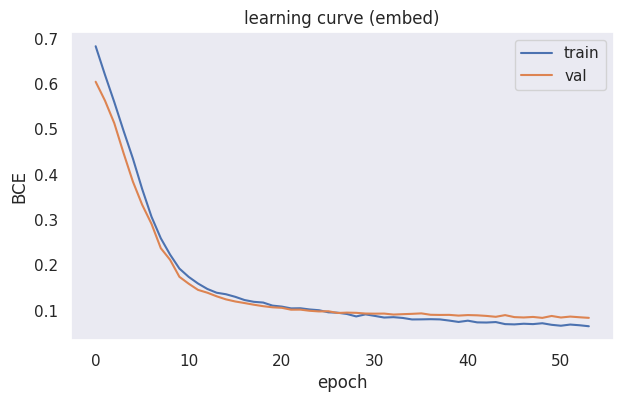

Chosen Threshold = 0.60


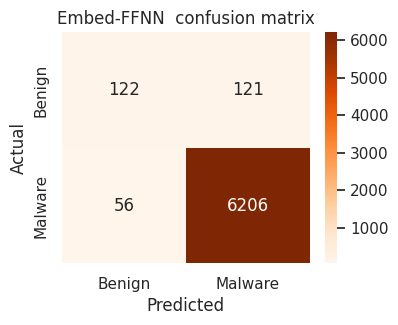

              precision    recall  f1-score   support

      Benign       0.69      0.50      0.58       243
     Malware       0.98      0.99      0.99      6262

    accuracy                           0.97      6505
   macro avg       0.83      0.75      0.78      6505
weighted avg       0.97      0.97      0.97      6505

F1-macro : 0.7828
ROC-AUC  : 0.9372
PR-AUC   : 0.9960


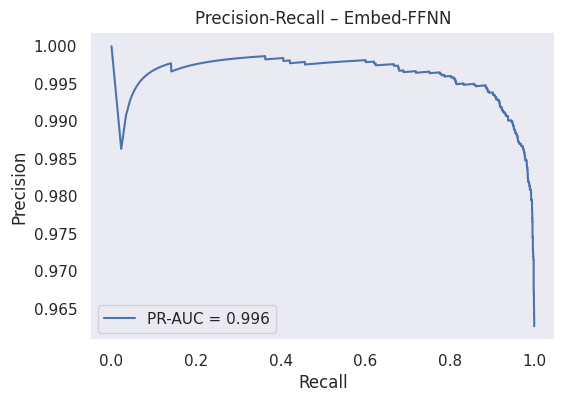

In [33]:

import torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, roc_auc_score,
                             precision_recall_curve, auc)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme()

# dataset and dataloader
Xtr = torch.tensor(X_train_padded, dtype=torch.long)
Xte = torch.tensor(X_test_padded,  dtype=torch.long)
ytr = torch.tensor(y_train,        dtype=torch.float32)
yte = torch.tensor(y_test,         dtype=torch.float32)

full_ds = TensorDataset(Xtr, ytr)
te_ds   = TensorDataset(Xte, yte)

tr_sz   = int(0.8 * len(full_ds))
val_sz  = len(full_ds) - tr_sz
tr_ds, val_ds = random_split(full_ds, [tr_sz, val_sz])

tr_ld  = DataLoader(tr_ds,  batch_size=64, shuffle=True)
val_ld = DataLoader(val_ds, batch_size=64, shuffle=False)
te_ld  = DataLoader(te_ds,  batch_size=64, shuffle=False)

class EmbedFFNN(nn.Module):
    def __init__(self, vocab_sz:int, emb_dim:int=64):
        super().__init__()
        self.emb  = nn.Embedding(vocab_sz+1, emb_dim, padding_idx=0)
        self.net  = nn.Sequential(
            nn.Linear(emb_dim, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.50),
            nn.Linear(256,  64),
            nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.50),
            nn.Linear(64, 1)                      # logits
        )
    def forward(self,x):

        z = self.emb(x).mean(dim=1)               # mean-pool (B,emb_dim)
        return self.net(z).squeeze(1)             # (B,)

vocab_sz = len(vocab)
model    = EmbedFFNN(vocab_sz).to(device)

# loss + optimization + scheduler
n_benign, n_malw = (y_train==0).sum(), (y_train==1).sum()
pos_w = torch.tensor([1.1], device=device)

crit      = nn.BCEWithLogitsLoss()  #pos_weight=pos_w
optimiser = optim.AdamW(model.parameters(), lr=5e-4)
sched     = optim.lr_scheduler.OneCycleLR(
              optimiser, max_lr=5e-4,
              epochs=100, steps_per_epoch=len(tr_ld))

# training
hist_tr, hist_val = [], []
best_val, wait, patience, epochs = 1e9, 0, 5, 100

for ep in range(1, epochs+1):
    # --- train ---
    model.train(); run=0.
    for x,y in tr_ld:
        x,y = x.to(device), y.to(device)
        optimiser.zero_grad()
        loss = crit(model(x), y)
        loss.backward(); optimiser.step(); sched.step()
        run += loss.item()*x.size(0)
    hist_tr.append(run/len(tr_ds))

    # --- val ---
    model.eval(); run=0.
    with torch.no_grad():
        for x,y in val_ld:
            x,y = x.to(device), y.to(device)
            run += crit(model(x), y).item()*x.size(0)
    val_loss = run/len(val_ds); hist_val.append(val_loss)
    print(f"Ep {ep:02d}  train={hist_tr[-1]:.4f}  val={val_loss:.4f}")

    if val_loss < best_val:
        best_val, wait, best_w = val_loss, 0, model.state_dict()
    else:
        wait += 1
        if wait >= patience:
            print("early-stop"); break

model.load_state_dict(best_w)

# Loss curve
plt.figure(figsize=(7,4))
plt.plot(hist_tr, label="train"); plt.plot(hist_val, label="val")
plt.xlabel("epoch"); plt.ylabel("BCE"); plt.title("learning curve (embed)")
plt.legend(); plt.grid(); plt.show()

# threshold validaition
model.eval(); p_val, y_val = [], []
with torch.no_grad():
    for x,y in val_ld:
        p_val.append(torch.sigmoid(model(x.to(device))).cpu())
        y_val.append(y)
p_val = torch.cat(p_val).numpy();  y_val = torch.cat(y_val).numpy()

thr_grid = np.linspace(0.05,0.95,19)
best_thr = thr_grid[np.argmax([f1_score(y_val, p_val>=t, average='macro')
                               for t in thr_grid])]
print(f"Chosen Threshold = {best_thr:.2f}")

# test set evaluation
p_test, y_test_arr = [], []
with torch.no_grad():
    for x,y in te_ld:
        p_test.append(torch.sigmoid(model(x.to(device))).cpu())
        y_test_arr.append(y)
p_test = torch.cat(p_test).numpy().ravel()
y_test_arr = torch.cat(y_test_arr).numpy().ravel()
pred   = (p_test >= best_thr).astype(int)

cm = confusion_matrix(y_test_arr, pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Benign','Malware'],
            yticklabels=['Benign','Malware'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Embed-FFNN  confusion matrix"); plt.show()

print(classification_report(y_test_arr, pred,
                            target_names=['Benign','Malware']))

f1m   = f1_score(y_test_arr, pred, average='macro')
roc   = roc_auc_score(y_test_arr, p_test)
prec, rec, _ = precision_recall_curve(y_test_arr, p_test)
prauc = auc(rec, prec)
print(f"F1-macro : {f1m:.4f}\nROC-AUC  : {roc:.4f}\nPR-AUC   : {prauc:.4f}")

plt.figure(figsize=(6,4))
plt.plot(rec, prec, label=f"PR-AUC = {prauc:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall – Embed-FFNN")
plt.grid(); plt.legend(); plt.show()


In [34]:
print("Value assigned to <UNK>:", api_to_int["<UNK>"])


Value assigned to <UNK>: 259


In [35]:
# Count how many times the <UNK> token appears in the test set sequences.”
unk_value = api_to_int["<UNK>"]
test_unknowns = test_df['seq_encoded'].apply(lambda seq: seq.count(unk_value))
print("Unknown token count per sequence (summary):")
print(test_unknowns.describe())


Unknown token count per sequence (summary):
count    6505.000000
mean        0.000461
std         0.021472
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: seq_encoded, dtype: float64


# Task 3 - RNN

RNN


In [36]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
import torch.optim as optim
import torch.nn as nn
import torch

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from scipy.io.arff import loadarff
from tqdm import tqdm
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# Function to visualize model performance by creating a confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    """
    Creates and displays a confusion matrix to evaluate classification performance.

    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        class_names: List of class names for axis labels
    """
    cm = confusion_matrix(y_true, y_pred)  # Compute confusion matrix

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

In [38]:
def training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, num_epochs, criterion):
    """
    Train the model for a specified number of epochs and track the training and validation losses.

    Args:
        model: The neural network model to be trained.
        train_loader: DataLoader for the training dataset.
        val_loader: DataLoader for the validation dataset.
        train_dataset: The entire training dataset.
        val_dataset: The entire validation dataset.
        device: Device to run the model on (CPU or GPU).
        optimizer: The optimization algorithm to use for updating model parameters.
        criterion: The loss function to use for computing the loss.

    Returns:
        None: The function plots the training and validation loss over the epochs.
    """


    # Record the start time
    start_time = time.time()


    train_losses = []
    val_losses = []

    # Training loop
    for epoch in range(num_epochs):  # Train for epochs
        train_loss = 0
        val_loss = 0
        model.train()  # Set model to training mode
        for batch_X, lengths, batch_y in train_loader:
            batch_X, lengths, batch_y = batch_X.to(device), lengths.to(device), batch_y.to(device)  # Move batch to GPU
            optimizer.zero_grad()  # Clear previous gradients
            outputs = model(batch_X,lengths)  # Forward pass
            loss = criterion(outputs, batch_y)  # Compute loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update model parameters
            train_loss += loss.item() * batch_X.size(0)
        train_loss /= len(train_dataset)
        train_losses.append(train_loss)  # Store training loss

        # Compute Validation loss during training
        model.eval()  # Set model to evaluation mode
        with torch.no_grad():  # Disable gradient computation for validation
            for batch_X, lengths, batch_y in val_loader:
                batch_X, lengths, batch_y = batch_X.to(device), lengths.to(device), batch_y.to(device)  # Move batch to GPU
                val_outputs = model(batch_X,lengths)  # Forward pass
                loss = criterion(val_outputs, batch_y)  # Compute validation loss
                val_loss += loss.item() * batch_X.size(0)
            val_loss /= len(val_dataset)
            val_losses.append(val_loss)  # Store validation loss
            if (epoch + 1) % 20 == 0:
                print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')


    # Record the end time
    end_time = time.time()
    # Calculate the elapsed time
    elapsed_time = end_time - start_time
    print(f'The function took {elapsed_time:.4f} seconds to execute.')

    # Plot the training and validation loss
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

    return

def testing_model(model, dataloader, device):
    """
    Evaluate the model on a given dataloader and compute accuracy.

    Args:
        model: The trained model.
        dataloader: DataLoader for the dataset.
        device: Device to run the model on (CPU or GPU).

    Returns:
        float: Accuracy of the model on the test dataset.
    """
    # Record the start time
    start_time = time.time()

    model.eval()  # Set the model to evaluation mode
    all_labels = []
    all_predictions = []

    with torch.no_grad():  # Disable gradient computation for efficiency
        for inputs, lengths, labels in dataloader:
            inputs, lengths, labels = inputs.to(device), lengths.to(device), labels.to(device)  # Move batch to GPU
            outputs = model(inputs,lengths)
            _, predicted = torch.max(outputs, 1)  # Get the class with highest score
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions) * 100

    # Define class names
    class_names = [f"Class {cls}" for cls in np.unique(y_train)]

    # Plot the confusion matrix
    plot_confusion_matrix(all_labels, all_predictions, class_names)

    # Record the end time
    end_time = time.time()
    # Calculate the elapsed time
    elapsed_time = end_time - start_time
    print(f'The function took {elapsed_time:.4f} seconds to execute.')

    return accuracy

### Simple one-directional RNN - 1 layer

Maximum Training Sequence Length: 90
Maximum Training Sequence Length: 100
Shape of padded training sequences: (16325, 90)
Shape of padded test sequences: (6505, 90)
SimpleRNNClassifier(
  (embedding): Embedding(260, 50, padding_idx=0)
  (rnn): RNN(50, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Epoch 1/100 - Train Loss: 0.2040, Val Loss: 0.1553
Epoch 2/100 - Train Loss: 0.1418, Val Loss: 0.1385
Epoch 3/100 - Train Loss: 0.1324, Val Loss: 0.1313
Epoch 4/100 - Train Loss: 0.1278, Val Loss: 0.1299
Epoch 5/100 - Train Loss: 0.1227, Val Loss: 0.1268
Epoch 6/100 - Train Loss: 0.1179, Val Loss: 0.1243
Epoch 7/100 - Train Loss: 0.1131, Val Loss: 0.1212
Epoch 8/100 - Train Loss: 0.1090, Val Loss: 0.1173
Epoch 9/100 - Train Loss: 0.1044, Val Loss: 0.1153
Epoch 10/100 - Train Loss: 0.1029, Val Loss: 0.1148
Epoch 11/100 - Train Loss: 0.0996, Val Loss: 0.1142
Epoch 12/100 - Train Loss: 0.0943, Val Loss: 0.1110
Epoch 13/100 - Train Loss: 

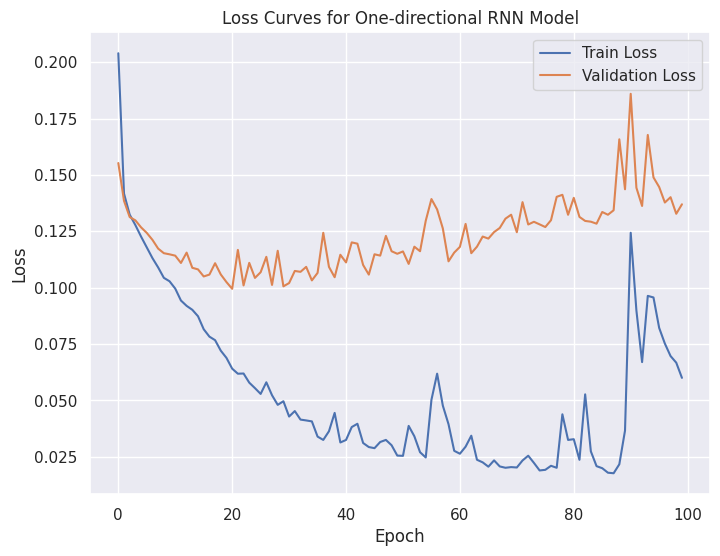

Confusion Matrix:
[[  54  189]
 [  79 6183]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.41      0.22      0.29       243
     Malware       0.97      0.99      0.98      6262

    accuracy                           0.96      6505
   macro avg       0.69      0.60      0.63      6505
weighted avg       0.95      0.96      0.95      6505



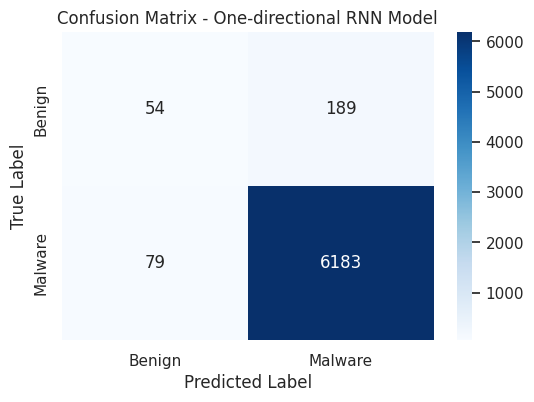

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import confusion_matrix, classification_report
from keras.utils import pad_sequences
import pandas as pd


# load data

max_len_train = train_df['seq_encoded'].apply(len).max()
print("Maximum Training Sequence Length:", max_len_train)

max_len_test = test_df['seq_encoded'].apply(len).max()
print("Maximum Training Sequence Length:", max_len_test)


train_df.drop_duplicates(subset=['seq_encoded'], inplace=True)
test_df.drop_duplicates(subset=['seq_encoded'], inplace=True)

#  (post-padding and post-truncation)
X_train_padded = pad_sequences(train_df['seq_encoded'], maxlen=max_len_train, padding='post', truncating='post')
X_test_padded  = pad_sequences(test_df['seq_encoded'], maxlen=max_len_train, padding='post', truncating='post')

print("Shape of padded training sequences:", X_train_padded.shape)
print("Shape of padded test sequences:", X_test_padded.shape)


y_train = train_df['is_malware'].values
y_test  = test_df['is_malware'].values



def compute_lengths(padded_sequences):

    return np.sum(padded_sequences != 0, axis=1)

train_lengths = compute_lengths(X_train_padded)
test_lengths  = compute_lengths(X_test_padded)

# Create a custom dataset that returns (sequence, length, label)
class APICallSequenceDataset(Dataset):
    def __init__(self, sequences, lengths, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        return self.sequences[idx], self.lengths[idx], self.labels[idx]

train_dataset = APICallSequenceDataset(X_train_padded, train_lengths, y_train)
test_dataset = APICallSequenceDataset(X_test_padded, test_lengths, y_test)

#  training (80%) and validation (20%)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# One directional RNN
class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size=1, num_layers=1):
        """
        Simple unidirectional RNN for classification.
        - vocab_size: Number of valid tokens (add 1 for padding).
        - embedding_dim: Dimension of the embeddings.
        - hidden_size: Dimension of the RNN hidden state.
        - output_size: For binary classification, 1.
        - num_layers: Number of RNN layers.
        """

        super(SimpleRNNClassifier, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size + 1, embedding_dim=embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(input_size=embedding_dim, hidden_size=hidden_size, num_layers=num_layers,
                          batch_first=True, bidirectional=False, nonlinearity="tanh")
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, lengths):
        # x: (batch_size, max_len)
        embedded = self.embedding(x)  # (batch_size, max_len, embedding_dim)
        # Pack the embedded sequences for efficient processing by the RNN
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, h_n = self.rnn(packed)
        hidden = h_n[-1]  # (batch_size, hidden_size)
        out = self.fc(hidden)  # (batch_size, output_size)
        out = self.sigmoid(out)
        return out


vocab_size = len(vocab)
embedding_dim = 50
hidden_size = 64

model_rnn = SimpleRNNClassifier(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_size=hidden_size, output_size=1, num_layers=1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_rnn = model_rnn.to(device)
print(model_rnn)

# loss function optimizer and scheduler
criterion = nn.BCELoss()
optimizer = optim.AdamW(model_rnn.parameters(), lr=0.0005)

num_epochs = 100
train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(num_epochs):
    model_rnn.train()
    running_loss = 0.0
    for batch in train_loader:
        sequences, lengths, labels = batch
        sequences, lengths, labels = sequences.to(device), lengths.to(device), labels.to(device).view(-1, 1)
        optimizer.zero_grad()
        outputs = model_rnn(sequences, lengths)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * sequences.size(0)
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model_rnn.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            sequences, lengths, labels = batch
            sequences, lengths, labels = sequences.to(device), lengths.to(device), labels.to(device).view(-1, 1)
            outputs = model_rnn(sequences, lengths)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * sequences.size(0)
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")

# loss curve of the RNN
plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves for One-directional RNN Model")
plt.legend()
plt.show()


# Evaluation with confusion martix
model_rnn.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch in test_loader:
        sequences, lengths, labels = batch
        sequences, lengths, labels = sequences.to(device), lengths.to(device), labels.to(device).view(-1, 1)
        outputs = model_rnn(sequences, lengths)
        preds = (outputs > 0.5).float()
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Benign', 'Malware']))

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - One-directional RNN Model")
plt.show()


# One-Directional Simple RNN, Bi-Directional RNN, LSTM One-Directional

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import confusion_matrix, classification_report
from keras.utils import pad_sequences
import pandas as pd


# Data Preparation and Dataset Creation

max_len_train = train_df['seq_encoded'].apply(len).max()
print("Maximum Training Sequence Length:", max_len_train)

max_len_test = test_df['seq_encoded'].apply(len).max()
print("Maximum Test Sequence Length:", max_len_test)


train_df.drop_duplicates(subset=['seq_encoded'], inplace=True)
test_df.drop_duplicates(subset=['seq_encoded'], inplace=True)

X_train_padded = pad_sequences(train_df['seq_encoded'], maxlen=max_len_train, padding='post', truncating='post')
X_test_padded  = pad_sequences(test_df['seq_encoded'], maxlen=max_len_train, padding='post', truncating='post')

print("Shape of padded training sequences:", X_train_padded.shape)
print("Shape of padded test sequences:", X_test_padded.shape)

y_train = train_df['is_malware'].values
y_test  = test_df['is_malware'].values

# Compute real sequence lengths (number of tokens != 0)
def compute_lengths(padded_sequences):
    return np.sum(padded_sequences != 0, axis=1)

train_lengths = compute_lengths(X_train_padded)
test_lengths  = compute_lengths(X_test_padded)

# Create custom dataset returning (sequence, length, label)
class APICallSequenceDataset(Dataset):
    def __init__(self, sequences, lengths, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        return self.sequences[idx], self.lengths[idx], self.labels[idx]

train_dataset = APICallSequenceDataset(X_train_padded, train_lengths, y_train)
test_dataset = APICallSequenceDataset(X_test_padded, test_lengths, y_test)

# Split training dataset into train (80%) and validation (20%)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)





Maximum Training Sequence Length: 90
Maximum Test Sequence Length: 100
Shape of padded training sequences: (16325, 90)
Shape of padded test sequences: (6505, 90)


In [41]:
# Simple One-Directional RNN
class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size=1, num_layers=1):
        """
        Simple unidirectional RNN for classification.
        """
        super(SimpleRNNClassifier, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size + 1, embedding_dim=embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(input_size=embedding_dim, hidden_size=hidden_size, num_layers=num_layers,
                          batch_first=True, bidirectional=False, nonlinearity="tanh")
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, h_n = self.rnn(packed)
        hidden = h_n[-1]
        out = self.fc(hidden)
        out = self.sigmoid(out)
        return out



In [42]:
# Bidirectional RNN
class BiRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size=1, num_layers=1):
        """
        Bidirectional RNN for classification.
        """
        super(BiRNNClassifier, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size + 1, embedding_dim=embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(input_size=embedding_dim, hidden_size=hidden_size, num_layers=num_layers,
                          batch_first=True, bidirectional=True, nonlinearity="tanh")
        # Hidden state dimension is multiplied by 2 due to bidirectional RNN
        self.fc = nn.Linear(hidden_size * 2, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, hidden = self.rnn(packed)
        # hidden shape: (num_layers * 2, batch_size, hidden_size)
        # For one-layer bidirectional RNN, hidden[-2] is last forward, hidden[-1] is last backward.
        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        out = self.fc(hidden_cat)
        out = self.sigmoid(out)
        return out



In [43]:
# LSTM Model
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size=1, num_layers=1):
        """
        LSTM for classification.
        """
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size + 1, embedding_dim=embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_size, num_layers=num_layers,
                            batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (hidden, cell) = self.lstm(packed)
        out = self.fc(hidden[-1])
        out = self.sigmoid(out)
        return out





In [44]:
# Hyperparameters and Device Setup

vocab_size = len(vocab)  # 'vocab' must be defined during the vocabulary creation phase.”
embedding_dim = 50
hidden_size = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")





In [45]:
# Training Function with Early Stopping

def train_model(model, train_loader, val_loader, num_epochs, patience, criterion, optimizer, device):
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses = []
    val_losses = []
    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for sequences, lengths, labels in train_loader:
            sequences, lengths, labels = sequences.to(device), lengths.to(device), labels.to(device).view(-1, 1)
            optimizer.zero_grad()
            outputs = model(sequences, lengths)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * sequences.size(0)
        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_val_loss = 0.0

        for sequences, lengths, labels in val_loader:
            sequences, lengths, labels = sequences.to(device), lengths.to(device), labels.to(device).view(-1, 1)
            outputs = model(sequences, lengths)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * sequences.size(0)
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        print(f"Epoch {epoch+1:02d}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    end_time = time.time()
    training_time = end_time - start_time
    print(f"Total training time: {training_time:.2f} seconds")
    model.load_state_dict(best_model_state)
    return train_losses, val_losses, training_time


# Evaluation Function

def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for sequences, lengths, labels in test_loader:
            sequences, lengths, labels = sequences.to(device), lengths.to(device), labels.to(device).view(-1, 1)
            outputs = model(sequences, lengths)
            preds = (outputs > 0.5).float()
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['Benign', 'Malware']))
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Train and Evaluate Each Model Variant

num_epochs = 100
patience = 10


--- Training Simple One-Directional RNN ---
Epoch 01/100 - Train Loss: 0.2139, Val Loss: 0.1493
Epoch 02/100 - Train Loss: 0.1387, Val Loss: 0.1411
Epoch 03/100 - Train Loss: 0.1319, Val Loss: 0.1381
Epoch 04/100 - Train Loss: 0.1265, Val Loss: 0.1318
Epoch 05/100 - Train Loss: 0.1222, Val Loss: 0.1315
Epoch 06/100 - Train Loss: 0.1194, Val Loss: 0.1253
Epoch 07/100 - Train Loss: 0.1149, Val Loss: 0.1246
Epoch 08/100 - Train Loss: 0.1120, Val Loss: 0.1187
Epoch 09/100 - Train Loss: 0.1075, Val Loss: 0.1212
Epoch 10/100 - Train Loss: 0.1030, Val Loss: 0.1171
Epoch 11/100 - Train Loss: 0.0997, Val Loss: 0.1204
Epoch 12/100 - Train Loss: 0.0951, Val Loss: 0.1092
Epoch 13/100 - Train Loss: 0.0904, Val Loss: 0.1119
Epoch 14/100 - Train Loss: 0.0903, Val Loss: 0.1174
Epoch 15/100 - Train Loss: 0.0864, Val Loss: 0.1117
Epoch 16/100 - Train Loss: 0.0806, Val Loss: 0.1107
Epoch 17/100 - Train Loss: 0.0777, Val Loss: 0.1076
Epoch 18/100 - Train Loss: 0.0720, Val Loss: 0.1074
Epoch 19/100 - Trai

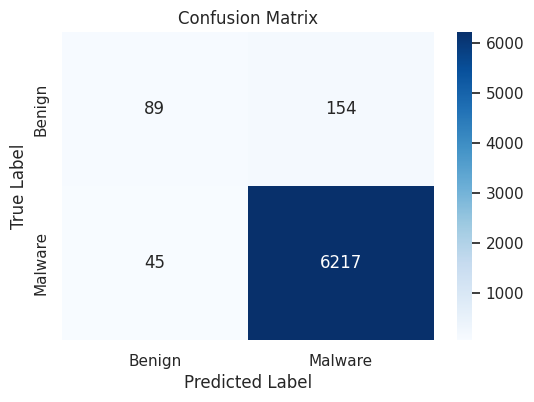

In [46]:
# Simple One-Directional RNN
print("\n--- Training Simple One-Directional RNN ---")
model_simple_rnn = SimpleRNNClassifier(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_size=hidden_size, output_size=1, num_layers=1)
model_simple_rnn = model_simple_rnn.to(device)
optimizer_simple = optim.AdamW(model_simple_rnn.parameters(), lr=0.0005)
criterion = nn.BCELoss()

train_losses_simple, val_losses_simple, time_simple = train_model(model_simple_rnn, train_loader, val_loader, num_epochs, patience, criterion, optimizer_simple, device)
print("Evaluating Simple One-Directional RNN on Test Set:")
evaluate_model(model_simple_rnn, test_loader, device)




--- Training Bidirectional RNN ---
Epoch 01/100 - Train Loss: 0.1929, Val Loss: 0.1476
Epoch 02/100 - Train Loss: 0.1346, Val Loss: 0.1367
Epoch 03/100 - Train Loss: 0.1260, Val Loss: 0.1362
Epoch 04/100 - Train Loss: 0.1200, Val Loss: 0.1272
Epoch 05/100 - Train Loss: 0.1155, Val Loss: 0.1246
Epoch 06/100 - Train Loss: 0.1124, Val Loss: 0.1400
Epoch 07/100 - Train Loss: 0.1146, Val Loss: 0.1271
Epoch 08/100 - Train Loss: 0.1052, Val Loss: 0.1250
Epoch 09/100 - Train Loss: 0.1006, Val Loss: 0.1142
Epoch 10/100 - Train Loss: 0.0905, Val Loss: 0.1106
Epoch 11/100 - Train Loss: 0.0867, Val Loss: 0.1101
Epoch 12/100 - Train Loss: 0.0837, Val Loss: 0.1114
Epoch 13/100 - Train Loss: 0.0772, Val Loss: 0.1131
Epoch 14/100 - Train Loss: 0.0740, Val Loss: 0.1090
Epoch 15/100 - Train Loss: 0.0700, Val Loss: 0.1033
Epoch 16/100 - Train Loss: 0.0662, Val Loss: 0.1175
Epoch 17/100 - Train Loss: 0.0668, Val Loss: 0.1069
Epoch 18/100 - Train Loss: 0.0590, Val Loss: 0.1044
Epoch 19/100 - Train Loss: 0

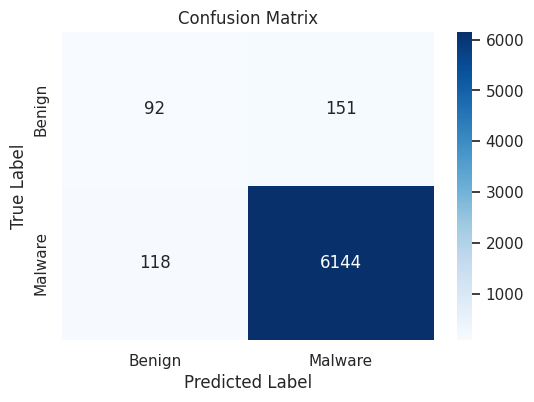

In [47]:
# Bidirectional RNN
print("\n--- Training Bidirectional RNN ---")
class BiRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size=1, num_layers=1):
        super(BiRNNClassifier, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size + 1, embedding_dim=embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(input_size=embedding_dim, hidden_size=hidden_size, num_layers=num_layers,
                          batch_first=True, bidirectional=True, nonlinearity="tanh")
        self.fc = nn.Linear(hidden_size * 2, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, hidden = self.rnn(packed)
        # hidden shape: (num_layers * 2, batch_size, hidden_size)
        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        out = self.fc(hidden_cat)
        out = self.sigmoid(out)
        return out

model_birnn = BiRNNClassifier(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_size=hidden_size, output_size=1, num_layers=1)
model_birnn = model_birnn.to(device)
optimizer_bi = optim.AdamW(model_birnn.parameters(), lr=0.0005)
train_losses_bi, val_losses_bi, time_bi = train_model(model_birnn, train_loader, val_loader, num_epochs, patience, criterion, optimizer_bi, device)
print("Evaluating Bidirectional RNN on Test Set:")
evaluate_model(model_birnn, test_loader, device)




--- Training LSTM Model ---
Epoch 01/100 - Train Loss: 0.2204, Val Loss: 0.1492
Epoch 02/100 - Train Loss: 0.1347, Val Loss: 0.1360
Epoch 03/100 - Train Loss: 0.1245, Val Loss: 0.1302
Epoch 04/100 - Train Loss: 0.1182, Val Loss: 0.1287
Epoch 05/100 - Train Loss: 0.1117, Val Loss: 0.1189
Epoch 06/100 - Train Loss: 0.1067, Val Loss: 0.1185
Epoch 07/100 - Train Loss: 0.1310, Val Loss: 0.1223
Epoch 08/100 - Train Loss: 0.1100, Val Loss: 0.1154
Epoch 09/100 - Train Loss: 0.1010, Val Loss: 0.1089
Epoch 10/100 - Train Loss: 0.0953, Val Loss: 0.1065
Epoch 11/100 - Train Loss: 0.0954, Val Loss: 0.1021
Epoch 12/100 - Train Loss: 0.0841, Val Loss: 0.0944
Epoch 13/100 - Train Loss: 0.0813, Val Loss: 0.0944
Epoch 14/100 - Train Loss: 0.0783, Val Loss: 0.0923
Epoch 15/100 - Train Loss: 0.0742, Val Loss: 0.0878
Epoch 16/100 - Train Loss: 0.0696, Val Loss: 0.0948
Epoch 17/100 - Train Loss: 0.0678, Val Loss: 0.0877
Epoch 18/100 - Train Loss: 0.0649, Val Loss: 0.0890
Epoch 19/100 - Train Loss: 0.0602, 

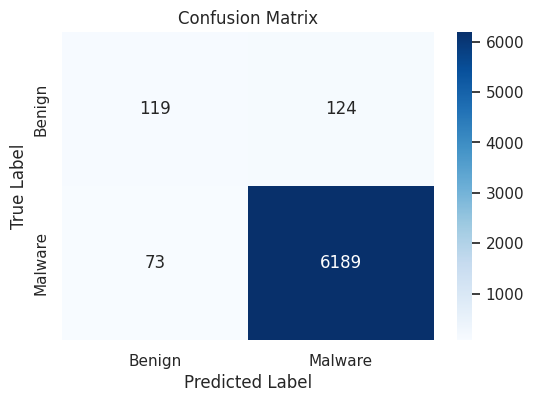

In [48]:
# LSTM Model
print("\n--- Training LSTM Model ---")
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size=1, num_layers=1):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size + 1, embedding_dim=embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_size, num_layers=num_layers,
                            batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (hidden, cell) = self.lstm(packed)
        out = self.fc(hidden[-1])
        out = self.sigmoid(out)
        return out

model_lstm = LSTMClassifier(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_size=hidden_size, output_size=1, num_layers=1)
model_lstm = model_lstm.to(device)
optimizer_lstm = optim.AdamW(model_lstm.parameters(), lr=0.0005)
train_losses_lstm, val_losses_lstm, time_lstm = train_model(model_lstm, train_loader, val_loader, num_epochs, patience, criterion, optimizer_lstm, device)
print("Evaluating LSTM Model on Test Set:")
evaluate_model(model_lstm, test_loader, device)



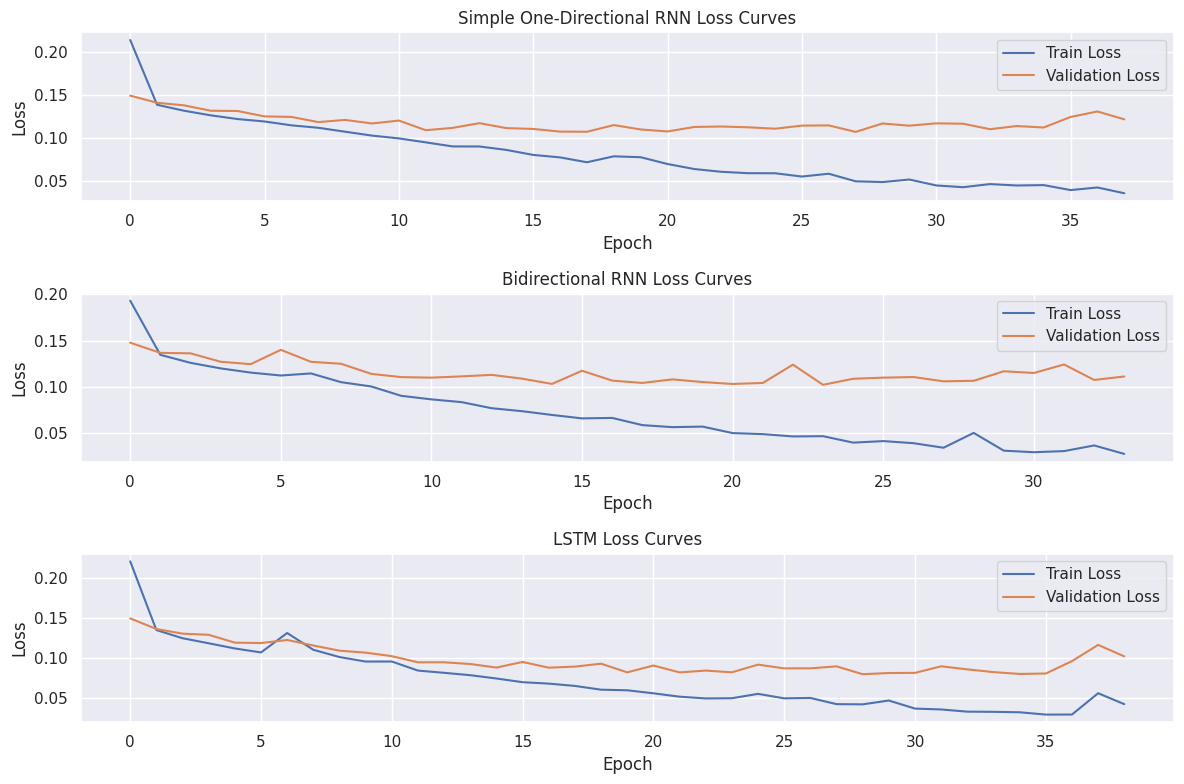

In [49]:
# -----------------------------
# Plot Loss Curves for All Variants

plt.figure(figsize=(12, 8))
plt.subplot(3,1,1)
plt.plot(train_losses_simple, label="Train Loss")
plt.plot(val_losses_simple, label="Validation Loss")
plt.title("Simple One-Directional RNN Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(3,1,2)
plt.plot(train_losses_bi, label="Train Loss")
plt.plot(val_losses_bi, label="Validation Loss")
plt.title("Bidirectional RNN Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(3,1,3)
plt.plot(train_losses_lstm, label="Train Loss")
plt.plot(val_losses_lstm, label="Validation Loss")
plt.title("LSTM Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()



In [50]:
# -----------------------------
# Print Training Times
# -----------------------------
print(f"Simple RNN training time: {time_simple:.2f} seconds")
print(f"Bidirectional RNN training time: {time_bi:.2f} seconds")
print(f"LSTM training time: {time_lstm:.2f} seconds")

Simple RNN training time: 58.37 seconds
Bidirectional RNN training time: 73.45 seconds
LSTM training time: 62.71 seconds


#  LSTM Bi-Directional

Maximum Training Sequence Length: 90
Maximum Test Sequence Length: 100
Shape of padded training sequences: (16325, 90)
Shape of padded test sequences: (6505, 90)
BiLSTMClassifier(
  (embedding): Embedding(260, 50, padding_idx=0)
  (lstm): LSTM(50, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Epoch 01/100 - Train Loss: 0.2048, Val Loss: 0.1377
Epoch 02/100 - Train Loss: 0.1326, Val Loss: 0.1283
Epoch 03/100 - Train Loss: 0.1197, Val Loss: 0.1238
Epoch 04/100 - Train Loss: 0.1093, Val Loss: 0.1102
Epoch 05/100 - Train Loss: 0.0999, Val Loss: 0.1031
Epoch 06/100 - Train Loss: 0.0884, Val Loss: 0.1004
Epoch 07/100 - Train Loss: 0.0820, Val Loss: 0.0903
Epoch 08/100 - Train Loss: 0.0766, Val Loss: 0.0867
Epoch 09/100 - Train Loss: 0.0717, Val Loss: 0.0865
Epoch 10/100 - Train Loss: 0.0653, Val Loss: 0.0853
Epoch 11/100 - Train Loss: 0.0672, Val Loss: 0.0799
Epoch 12/100 - Train Loss: 0.0613, Val Loss: 0.0770
Ep

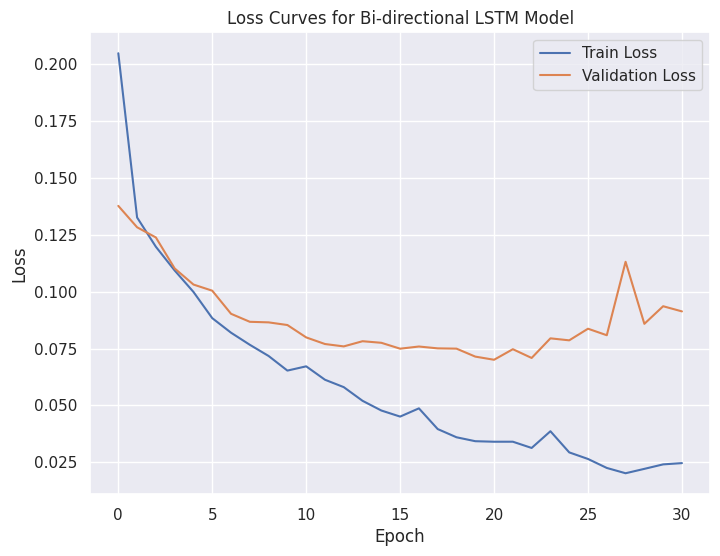

Confusion Matrix:
[[ 136  107]
 [  49 6213]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.74      0.56      0.64       243
     Malware       0.98      0.99      0.99      6262

    accuracy                           0.98      6505
   macro avg       0.86      0.78      0.81      6505
weighted avg       0.97      0.98      0.97      6505



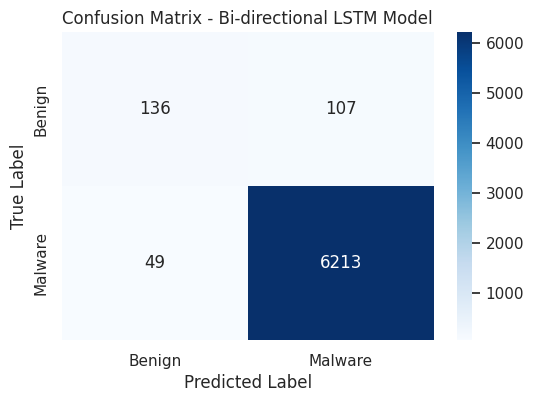

In [57]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import confusion_matrix, classification_report
from keras.utils import pad_sequences
import pandas as pd

# Step 1: Load Data, Drop Duplicates, Encode and Pad Sequences

max_len_train = train_df['seq_encoded'].apply(len).max()
print("Maximum Training Sequence Length:", max_len_train)

max_len_test = test_df['seq_encoded'].apply(len).max()
print("Maximum Test Sequence Length:", max_len_test)


train_df.drop_duplicates(subset=['seq_encoded'], inplace=True)
test_df.drop_duplicates(subset=['seq_encoded'], inplace=True)


X_train_padded = pad_sequences(train_df['seq_encoded'], maxlen=max_len_train, padding='post', truncating='post')
X_test_padded  = pad_sequences(test_df['seq_encoded'], maxlen=max_len_train, padding='post', truncating='post')

print("Shape of padded training sequences:", X_train_padded.shape)
print("Shape of padded test sequences:", X_test_padded.shape)

y_train = train_df['is_malware'].values
y_test  = test_df['is_malware'].values

# Compute Sequence Lengths and Create Custom Dataset

def compute_lengths(padded_sequences):

    return np.sum(padded_sequences != 0, axis=1)

train_lengths = compute_lengths(X_train_padded)
test_lengths  = compute_lengths(X_test_padded)

class APICallSequenceDataset(Dataset):
    def __init__(self, sequences, lengths, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        return self.sequences[idx], self.lengths[idx], self.labels[idx]

train_dataset = APICallSequenceDataset(X_train_padded, train_lengths, y_train)
test_dataset = APICallSequenceDataset(X_test_padded, test_lengths, y_test)

#  training (80%) and validation (20%)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)


# Define a Bi-Directional LSTM Classifier Model

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size=1, num_layers=1):
        """
        Bi-Directional LSTM classifier for API call sequences.

        Args:
            vocab_size (int): Number of valid tokens (excluding padding).
            embedding_dim (int): Dimension of the embeddings.
            hidden_size (int): Dimension of the LSTM hidden state.
            output_size (int): Dimension of the output (1 for binary classification).
            num_layers (int): Number of LSTM layers.

        Note: num_embeddings is set to vocab_size + 1 to reserve index 0 for padding.
        """

        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size + 1,
                                      embedding_dim=embedding_dim,
                                      padding_idx=0)
        self.lstm = nn.LSTM(input_size=embedding_dim,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            bidirectional=True)

        self.fc = nn.Linear(hidden_size * 2, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, lengths):

        embedded = self.embedding(x)  # (batch_size, max_len, embedding_dim)
        # Pack the sequence for efficient LSTM computation
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (hidden, cell) = self.lstm(packed)
        # hidden shape: (num_layers * 2, batch_size, hidden_size)
        hidden_forward = hidden[-2]
        hidden_backward = hidden[-1]
        hidden_cat = torch.cat((hidden_forward, hidden_backward), dim=1)  # (batch_size, hidden_size*2)
        out = self.fc(hidden_cat)
        out = self.sigmoid(out)
        return out


vocab_size = len(vocab)
embedding_dim = 50
hidden_size = 64

model_lstm_bi = BiLSTMClassifier(vocab_size=vocab_size, embedding_dim=embedding_dim,
                                  hidden_size=hidden_size, output_size=1, num_layers=1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_lstm_bi = model_lstm_bi.to(device)
print(model_lstm_bi)

# Configure Loss Function, Optimizer, and Training Loop with Early Stopping

criterion = nn.BCELoss().to(device)
optimizer = optim.AdamW(model_lstm_bi.parameters(), lr=0.0005)

num_epochs = 100
patience = 10
best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(num_epochs):
    model_lstm_bi.train()
    running_loss = 0.0
    for sequences, lengths, labels in train_loader:
        sequences, lengths, labels = sequences.to(device), lengths.to(device), labels.to(device).view(-1, 1)
        optimizer.zero_grad()
        outputs = model_lstm_bi(sequences, lengths)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * sequences.size(0)
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model_lstm_bi.eval()
    running_val_loss = 0.0
    for sequences, lengths, labels in val_loader:
        sequences, lengths, labels = sequences.to(device), lengths.to(device), labels.to(device).view(-1, 1)
        outputs = model_lstm_bi(sequences, lengths)
        loss = criterion(outputs, labels)
        running_val_loss += loss.item() * sequences.size(0)
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1:02d}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        best_model_state = model_lstm_bi.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")

model_lstm_bi.load_state_dict(best_model_state)

# Plot Loss Curves for the Bi-directional LSTM Model

plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves for Bi-directional LSTM Model")
plt.legend()
plt.show()

# -----------------------------
# Evaluate the Bi-directional LSTM Model on the Test Set
# -----------------------------
model_lstm_bi.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for sequences, lengths, labels in test_loader:
        sequences, lengths, labels = sequences.to(device), lengths.to(device), labels.to(device).view(-1, 1)
        outputs = model_lstm_bi(sequences, lengths)
        preds = (outputs > 0.5).float()
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Benign', 'Malware']))

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Bi-directional LSTM Model")
plt.show()


In [58]:
cd /content/sample_data

/content/sample_data


In [59]:
!jupyter nbconvert --to html Final_Lab2_RNN.ipynb

[NbConvertApp] Converting notebook Final_Lab2_RNN.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 26 image(s).
[NbConvertApp] Writing 1978245 bytes to Final_Lab2_RNN.html
